<a href="https://colab.research.google.com/github/Crisperez517/VERANO-DELFIN/blob/main/VERANO_DELFIN_SIMULACION_CODIGO_DE_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación Estocástica y Análisis de Riesgo en la Red de Frío para Vacunas
### Evaluación del Refrigerador Haier HBC-150 bajo Condiciones Críticas en Tuxtla Gutiérrez, Chiapas

**Programa:** Verano de la Investigación Científica y Tecnológica del Pacífico (Programa Delfín)

**Autor:** Cristóbal Pérez González

**Asesor / Investigador:** Dr. Yofre Hernan García Gómez

---

### Descripción del Proyecto
Este cuaderno contiene el código de la simulación computacional desarrollado durante la estancia de investigación. Su objetivo es modelar la dinámica térmica, eléctrica y logística de un refrigerador institucional de vacunas operando en escenarios reales de estrés.

Debido a la naturaleza aleatoria de las fallas en el suministro eléctrico y la manipulación humana del equipo, el comportamiento del sistema no posee una solución analítica exacta. Por ello, este código resuelve el problema acoplando cálculo estocástico, farmacología y el método de Montecarlo.

### Metodología y Arquitectura del Código:
1. **Entorno Climático:** Modelado continuo del clima de Tuxtla Gutiérrez mediante la interpolación de datos reales (CSV) y la superposición de ondas senoidales para simular el estrés térmico máximo diario a las 15:00 horas.
2. **Infraestructura Eléctrica (CFE) y Aperturas:** Simulación de los cortes de luz mediante un **Proceso de Poisson No Homogéneo** (con picos en temporadas de calor y tormentas) y duraciones de apagón extraídas de distribuciones Log-Normales estacionales.
3. **Termodinámica (SDE):** Integración numérica de la temperatura interna del refrigerador utilizando una **Ecuación Diferencial Estocástica de Ornstein-Uhlenbeck** (Esquema de Euler-Maruyama), integrando cambios de régimen dinámicos (*Regime-Switching*) para simular la pérdida de frío pasiva vs. el enfriamiento activo.
4. **Cinética de Degradación:** Evaluación de la pérdida de viabilidad del biológico aplicando la **Ecuación de Arrhenius** (penalizando las temperaturas $>8^\circ$C) acoplada a un modelo logístico de control de inventario de 5,000 dosis.
5. **Motor Estocástico:** Bucle de **Montecarlo (1,000 trayectorias anuales)** para estabilizar el sistema mediante la Ley de los Grandes Números y extraer el *Value at Risk (VaR)* y probabilidades definitivas del riesgo de merma.

---
*Instrucciones de uso: Ejecutar las celdas de forma secuencial. Las gráficas estáticas y métricas que se imprimen en la consola final corresponden a la estadística descriptiva utilizada en el reporte de la investigación.*

## Celda 1: Procesamiento de la Serie de Tiempo y Función de Temperatura $T_{amb}(t)$

En esta primera sección preparamos el "motor temporal" y el entorno climático de nuestra simulación estocástica, basándonos en los registros meteorológicos extremos reales de Tuxtla Gutiérrez para el año 2024.

1. **Calendario Logístico:** Extraemos los días de la semana para identificar la jornada hábil (Lunes a Viernes) y los fines de semana. Esto es crucial porque los eventos que alteran la termodinámica del equipo (como las aperturas de puerta para extracción de vacunas) ocurren exclusivamente durante los días operativos de la clínica.
2. **Clima y Función Determinista $T_{amb}(t)$:** Cargamos la temperatura promedio diaria ($t_{avg}$) desde nuestra base de datos. Dado que la Ecuación Diferencial Estocástica (EDE) requiere integración continua, construimos una malla de tiempo para cada intervalo de 5 minutos ($\Delta t = 5/60$). Para modelar el estrés térmico máximo diario, sobreponemos al promedio una onda senoidal con una amplitud térmica de $7^\circ\text{C}$ (simulando un diferencial típico de 14°C entre la madrugada y la tarde). El argumento del coseno está desfasado para forzar matemáticamente que el pico absoluto de calor golpee al refrigerador exactamente a las 15:00 horas todos los días.
3. **Validación Gráfica:** Comparamos visualmente el vector de temperatura diaria base contra nuestra nueva función estocástica continua intradiaria.

Pasos totales de simulación: 105408 iteraciones de 5 minutos.



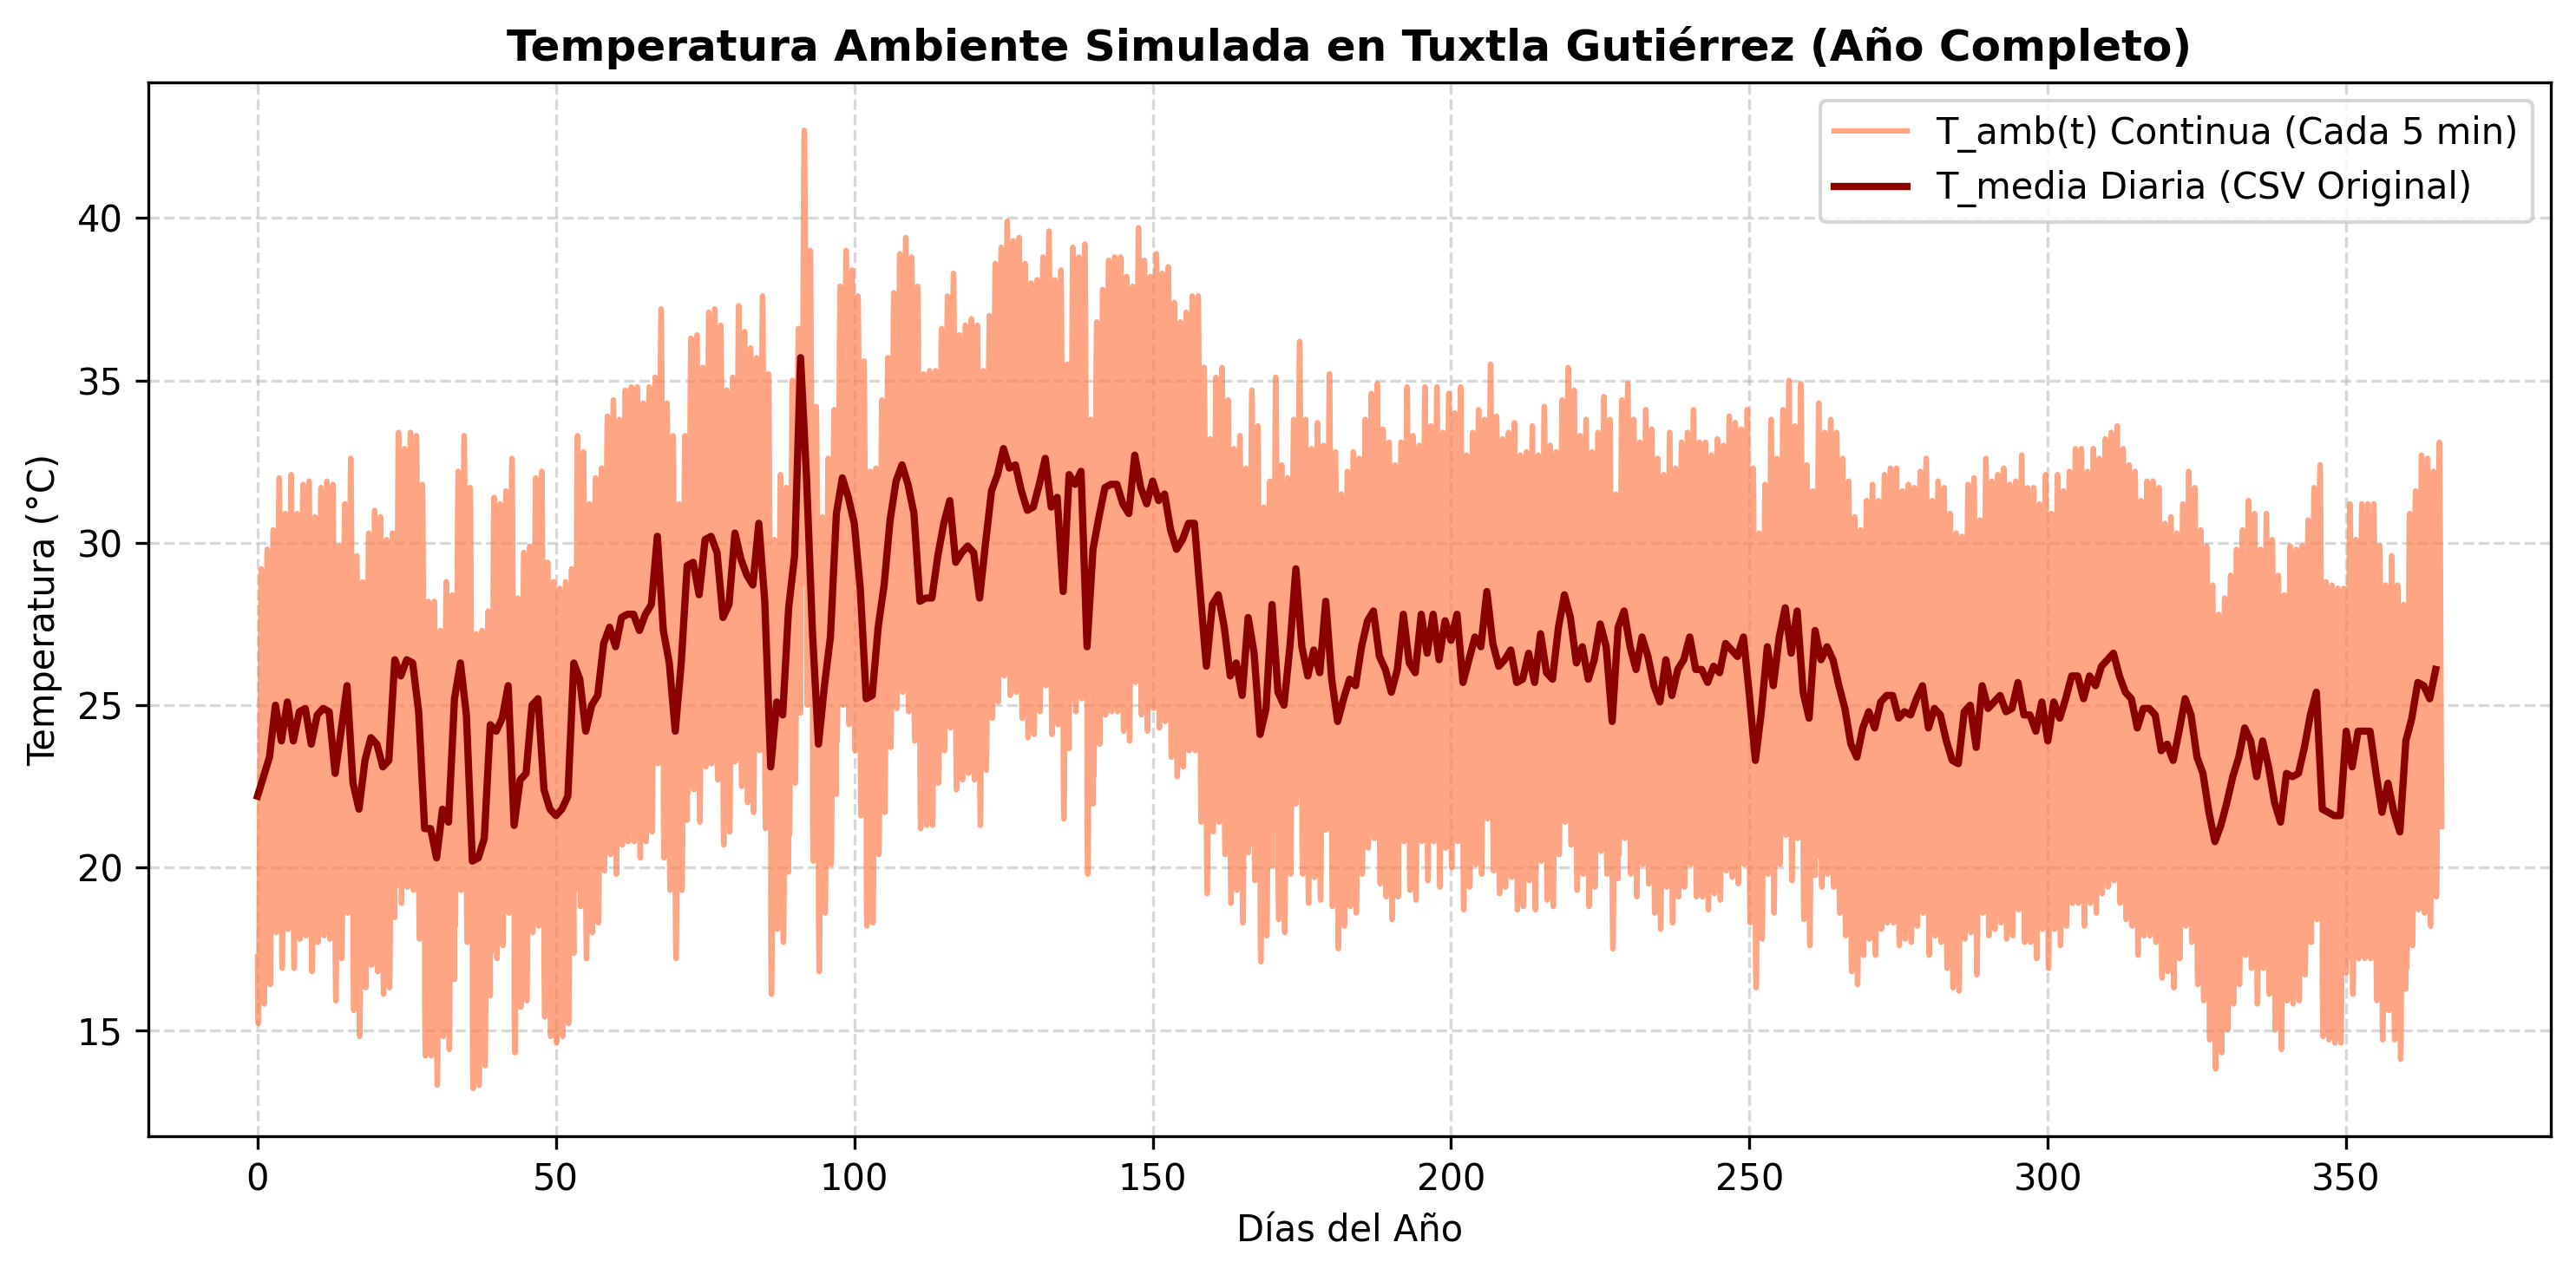

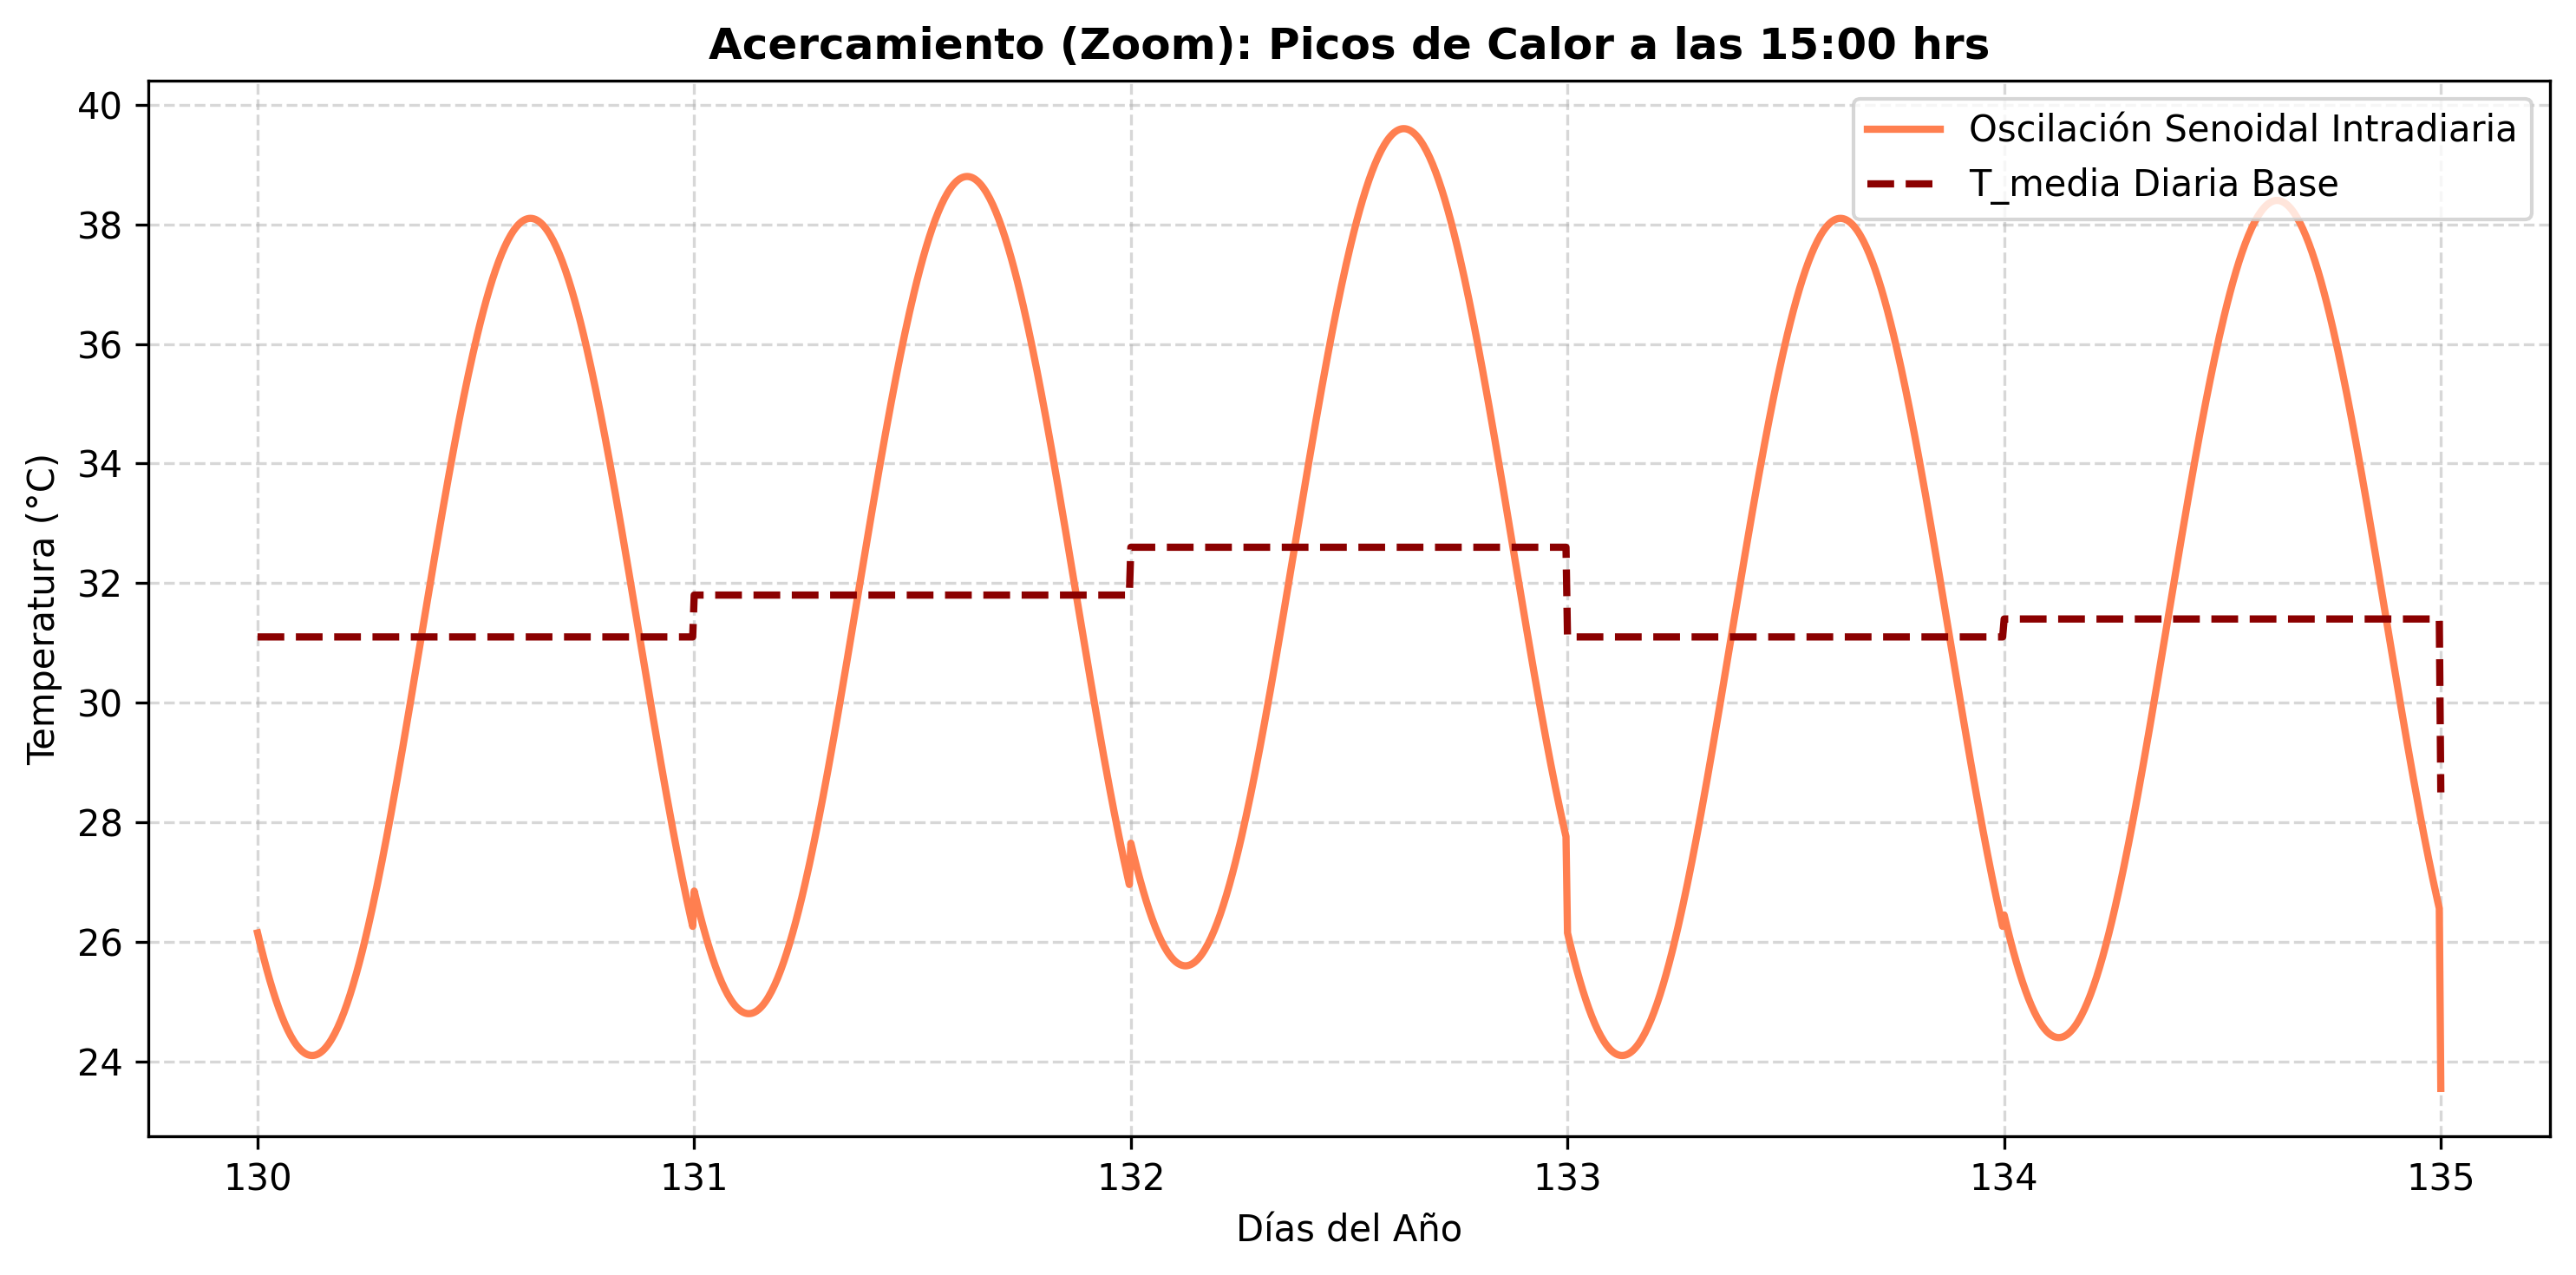

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS Y PREPARACIÓN DEL CALENDARIO LOGÍSTICO
ruta_csv = "/content/drive/MyDrive/CLIMA TUXLTA/CLIMA. TUXTLA/Clima de Tuxtla 2024.csv"
df = pd.read_csv(ruta_csv)

# Asegurar el formato de fecha y ordenar cronológicamente
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Creamos un arreglo booleano: True si es fin de semana (sábado=5, domingo=6), False si es hábil
df['es_fin_de_semana'] = df['date'].dt.dayofweek >= 5

# Extraemos la columna de temperatura e interpolamos los posibles valores nulos (NaNs)
df['tavg'] = df['tavg'].interpolate(method='linear')
T_diaria = df['tavg'].values               # Array de temperaturas diarias (366 días, 2024 fue bisiesto)
es_finde_diario = df['es_fin_de_semana'].values # Array logístico (366 días)

# 2. CREACIÓN DEL VECTOR DE TIEMPO (dt)
# Definimos el paso de integración en horas (5 minutos = 5/60 horas)
dt = 5 / 60.0
horas_totales = len(T_diaria) * 24
t_horas = np.arange(0, horas_totales, dt)

# 3. CONSTRUCCIÓN DE LA FUNCIÓN DETERMINISTA T_amb(t)
# Mapeamos la temperatura media a cada paso de 5 minutos
indices_dia = np.floor(t_horas / 24).astype(int)
indices_dia = np.clip(indices_dia, 0, len(T_diaria)-1) # Evitamos el desbordamiento de índice al final
T_media_expandida = T_diaria[indices_dia]

# Expandimos también el vector logístico para saber si cada paso de 5 min cae en fin de semana
es_finde_expandido = es_finde_diario[indices_dia]

# Sobreponemos la oscilación diurna para capturar el estrés térmico intradiario.
# Amplitud de 7°C, con el argumento del coseno ajustado (-15) para tener el pico a las 15:00 hrs.
amplitud_diurna = 7.0
T_amb_t = T_media_expandida + amplitud_diurna * np.cos(2 * np.pi * (t_horas - 15) / 24)

print(f"Pasos totales de simulación: {len(t_horas)} iteraciones de {dt*60:.0f} minutos.\n")

# 4. GRÁFICA DEL CLIMA
# --- GRÁFICA 1: Panorama Anual ---
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas / 24, T_amb_t, color='coral', alpha=0.7, label='T_amb(t) Continua (Cada 5 min)')
plt.plot(np.arange(len(T_diaria)), T_diaria, color='darkred', lw=2, label='T_media Diaria (CSV Original)')
plt.title('Temperatura Ambiente Simulada en Tuxtla Gutiérrez (Año Completo)', fontweight='bold', fontsize=12)
plt.xlabel('Días del Año')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('temp_anual_tuxtla.png', dpi=300)
plt.show()

# --- GRÁFICA 2: Zoom ---
dia_inicio_zoom = 130
dia_fin_zoom = 135
mascara_zoom = (t_horas >= dia_inicio_zoom * 24) & (t_horas <= dia_fin_zoom * 24)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas[mascara_zoom] / 24, T_amb_t[mascara_zoom], color='coral', lw=2, label='Oscilación Senoidal Intradiaria')
plt.plot(t_horas[mascara_zoom] / 24, T_media_expandida[mascara_zoom], color='darkred', lw=2, linestyle='--', label='T_media Diaria Base')
plt.title('Acercamiento (Zoom): Picos de Calor a las 15:00 hrs', fontweight='bold', fontsize=12)
plt.xlabel('Días del Año')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('temp_zoom_tuxtla.png', dpi=300)
plt.show()

## Celda 2: Calibración Física de la EDE y Reglas de la Clínica

En esta celda definimos las constantes físicas de nuestro refrigerador y las reglas operativas de la clínica simulada. Hacemos lo siguiente:

1. **Parámetros Termodinámicos:** Asignamos los valores exactos que calibramos para el equipo Haier HBC-150 ($\kappa_{on}$, $\kappa_{off}$, $\sigma_{on}$, $\sigma_{off}$), asegurando que la Ecuación Diferencial Estocástica (EDE) se comporte de forma realista tanto cuando hay luz como cuando ocurre un apagón.
2. **Cinética de Degradación:** Definimos las constantes de la ecuación de Arrhenius ($E_a$, factor $A$) que usaremos en la simulación para calcular el daño de las vacunas si el equipo se calienta.
3. **Aperturas de Puerta:** Programamos la normativa operativa. Creamos una apertura fija y obligatoria a las 8:00 de la mañana (para que las enfermeras saquen los biológicos del día). Para la tarde, programamos una tasa de probabilidad (Proceso de Poisson) que nos dará en promedio una apertura aleatoria entre las 15:00 y las 17:00 horas (para guardar los sobrantes). Ambas acciones las apagamos automáticamente en fines de semana, ya que la clínica no da consultas.

In [ ]:
# 1. PARÁMETROS TERMODINÁMICOS DE LA SDE (REFRIGERADOR HAIER HBC-150)

kappa_on = 0.1188   # Velocidad de enfriamiento rápido (compresor encendido)
kappa_off = 0.0178 # Pérdida térmica muy lenta por el aislamiento (apagón)
theta_set = 4.0     # Temperatura ideal programada en el termostato (°C)

sigma_on = 0.325    # Fluctuaciones del motor encendido (mantiene el rango +/- 2°C)
sigma_off = 0.05    # Ruido térmico pasivo por filtraciones de aire

T_0 = 4.0           # Temperatura inicial del equipo al arrancar la simulación

# 2. PARÁMETROS DEL DAÑO TÉRMICO (ECUACIÓN DE ARRHENIUS)

Ea = 85000.0        # Energía de activación para vacunas vivas atenuadas (J/mol)
R_gas = 8.314       # Constante universal de los gases
A_factor = 1.2e14   # Factor pre-exponencial calibrado

# 3. LÓGICA DE APERTURAS DE PUERTA

gamma_salto = 1   # Grados centígrados que sube la temperatura al abrir la puerta

# Identificamos la hora exacta del día en nuestro vector de tiempo continuo
hora_dia = t_horas % 24

# Regla A: Apertura matutina fija
# Creamos un arreglo booleano que será True exactamente a las 8:00 AM
apertura_manana_fija = np.isclose(hora_dia, 8.0)
# Bloqueamos que alguien abra la puerta en fines de semana
apertura_manana_fija[es_finde_expandido] = False

# Regla B: Apertura vespertina aleatoria (Proceso de Poisson)
# Queremos en promedio 1 apertura en la tarde (entre las 15:00 y las 17:00 hrs)
# Si repartimos 1 evento en 2 horas, la tasa es 0.5 aperturas por hora
lambda_tarde_hora = 0.5
lambda_puerta = np.zeros_like(t_horas)

# Activamos la probabilidad del Poisson solo en la tarde
mask_tarde = (hora_dia >= 15) & (hora_dia < 17)
lambda_puerta[mask_tarde] = lambda_tarde_hora

# Apagamos la probabilidad por completo en fines de semana
lambda_puerta[es_finde_expandido] = 0.0

print("Parámetros termodinámicos, de Arrhenius y reglas de puerta definidos correctamente.")

Parámetros termodinámicos, de Arrhenius y reglas de puerta definidos correctamente.


## Celda 3: Parámetros Estocásticos del Suministro Eléctrico (CFE)

En esta celda modelamos el riesgo externo que sufre la red eléctrica. Como vimos en nuestro análisis de datos, el clima afecta fuertemente la infraestructura, por lo que los apagones no ocurren de la misma forma todo el año. Para simular esto en código, definimos dos funciones:

1. **Frecuencia de Apagones:** Programamos la función `tasa_cortes_cfe(t)`, que representa la intensidad $\lambda(t)$ de nuestro Proceso de Poisson No Homogéneo. Aquí sumamos el riesgo base (fallas aleatorias) con dos campanas gaussianas que simulan los picos exactos que calculamos: el estrés por la ola de calor (centrado a inicios de junio) y la temporada de huracanes (centrada a inicios de septiembre).
2. **Duración de Apagones:** Programamos una función que nos devuelve los parámetros $\mu$ y $\sigma$ de una distribución Log-Normal dependiendo del día del año en el que estemos simulando.

In [ ]:
# 1. MODELO DE ESTADO ELÉCTRICO S(t) - FRECUENCIA DE APAGONES

def tasa_cortes_cfe(dia_del_ano):
    """
    Intensidad diaria de fallas (Proceso de Poisson No Homogéneo).
    Nos dice qué tan probable es que ocurra un apagón en un día específico del año.
    """
    # Riesgo base mínimo todo el año (mantenimiento o fallas locales)
    base = 0.0667

    # Pico 1: Temporada de calor extremo (Centro en el día 152, varianza ensanchada a 3200)
    k1 = 0.2333 * np.exp(-((dia_del_ano - 152)**2) / 3200)

    # Pico 2: Temporada de lluvias y tormentas (Centro en el día 244, varianza de 1800)
    k2 = 0.2333 * np.exp(-((dia_del_ano - 244)**2) / 1800)

    return base + k1 + k2

# 2. DURACIÓN DEL APAGÓN - DISTRIBUCIÓN LOG-NORMAL

# Diccionario con los parámetros (mu, sigma) exactos que calibramos con el Método de Momentos.
parametros_duracion = {
    'Base':   {'mu': 0.7933, 'sigma': 0.6838}, # Invierno y meses tranquilos
    'Calor':  {'mu': 0.8529, 'sigma': 0.2485}, # Mayo a Julio (Cortes más largos por calor)
    'Lluvia': {'mu': 0.4667, 'sigma': 0.3371}  # Agosto a Octubre (Cortes rápidos por lluvia)
}

def obtener_parametros_lognormal(dia_del_ano):
    """
    Revisa en qué día del año estamos y nos devuelve los parámetros correctos
    para simular la duración del apagón.
    """
    if 121 <= dia_del_ano <= 212:
        # Temporada: Mayo - Julio (Estrés Térmico)
        return parametros_duracion['Calor']['mu'], parametros_duracion['Calor']['sigma']

    elif 213 <= dia_del_ano <= 304:
        # Temporada: Agosto - Octubre (Tormentas/Huracanes)
        return parametros_duracion['Lluvia']['mu'], parametros_duracion['Lluvia']['sigma']

    else:
        # Temporada: Noviembre - Abril (Clima base)
        return parametros_duracion['Base']['mu'], parametros_duracion['Base']['sigma']

print("Funciones y parámetros del suministro eléctrico (CFE) cargados correctamente.")

Funciones y parámetros del suministro eléctrico (CFE) cargados correctamente.


## Celda 4: Generación de Trayectorias de Red Eléctrica y Saltos

En esta celda pre-calculamos de forma vectorizada los dos procesos estocásticos externos que golpearán a nuestra SDE en la simulación:

1. **Estado Eléctrico $S(t)$:** Recorremos todos los días del año. Para cada día, hacemos un muestreo de Poisson utilizando nuestra tasa de fallas de la CFE ($\lambda(t)$). Si ocurre un apagón, calculamos cuánto dura utilizando la distribución Log-Normal calibrada a esa estación climática específica y "apagamos" el vector $S(t)$ (cambiando su valor de 1 a 0 durante esas horas).
2. **Proceso de Saltos (Aperturas):** Generamos el vector que nos dirá exactamente en qué momento ocurren las aperturas de puerta. Aplicamos la probabilidad de Poisson de la tarde y le sumamos la apertura fija de la mañana. Finalmente, multiplicamos todo este proceso por $S(t)$, esto asegura (como regla operativa) que si no hay luz en la clínica, el personal tiene estrictamente prohibido abrir el refrigerador.

In [ ]:
np.random.seed(42) # Fijamos semilla para que el reporte sea reproducible

# 1. GENERACIÓN DE APAGONES - ESTADO ELÉCTRICO S(t)
# Inicializamos asumiendo que hay luz (1) todo el año
S_t = np.ones(len(t_horas))
dias_totales = int(np.ceil(t_horas[-1] / 24))

for dia in range(dias_totales):

    # Obtenemos la probabilidad de que falle la luz hoy
    tasa_hoy = tasa_cortes_cfe(dia)

    # Proceso de Poisson:
    num_cortes = np.random.poisson(tasa_hoy)

    for _ in range(num_cortes):
        # Si hubo corte, decidimos a qué hora exacta del día empezó
        hora_inicio = (dia * 24) + np.random.uniform(0, 24)

        # Consultamos cuánto va a durar el apagón según la estación
        mu_ln, sigma_ln = obtener_parametros_lognormal(dia)
        duracion_horas = np.random.lognormal(mu_ln, sigma_ln)

        # Convertimos las horas a índices de nuestro vector de 5 minutos
        idx_inicio = int(hora_inicio / dt)
        idx_fin = int((hora_inicio + duracion_horas) / dt)

        # Apagamos el suministro (0) en ese intervalo
        if idx_inicio < len(S_t):
            idx_fin = min(idx_fin, len(S_t))
            S_t[idx_inicio:idx_fin] = 0

transiciones = np.sum(np.diff(S_t) == -1)
print(f"Trayectoria eléctrica S(t) generada. Ocurrieron {transiciones} apagones en el año de prueba.")

# 2. GENERACIÓN DEL PROCESO DE SALTOS (Aperturas de Puerta)
# =====================================================================
# Array donde registraremos cuántos grados sube la temperatura en cada paso dt
Saltos_Termicos_t = np.zeros(len(t_horas))

# A. Agregamos las aperturas de la tarde (Estocásticas)
esperados_dt = lambda_puerta * dt
dN_t_tarde = np.random.poisson(esperados_dt)

# B. Agregamos las aperturas de la mañana (Deterministas / Fijas)
# Convertimos el array booleano de la mañana a números (1 = se abrió, 0 = no se abrió)
dN_t_manana = apertura_manana_fija.astype(int)

# Sumamos todas las aperturas del día
dN_t_total = dN_t_tarde + dN_t_manana

# Regla estricta: Si no hay luz (S_t == 0), las aperturas se cancelan
dN_t_total = dN_t_total * S_t

# Por cada apertura, el equipo sufrirá un impacto térmico de gamma (+1°C)
Saltos_Termicos_t = dN_t_total * gamma_salto

aperturas_totales = np.sum(dN_t_total)
print(f"Vector de saltos generado. La puerta se abrió {aperturas_totales:.0f} veces en el año.")

Trayectoria eléctrica S(t) generada. Ocurrieron 68 apagones en el año de prueba.
Vector de saltos generado. La puerta se abrió 508 veces en el año.


## Celda 5: Resolución Numérica de la SDE y Daño Térmico

En esta celda integramos paso a paso nuestra Ecuación Diferencial Estocástica acoplada con la cinética de Arrhenius. Hacemos lo siguiente:

1. **Integración Numérica (Euler-Maruyama):** Para resolver la SDE numéricamente, evaluamos usar el esquema de Milstein. Sin embargo, en nuestro modelo de Ornstein-Uhlenbeck, el coeficiente de difusión (la volatilidad $\sigma$) es constante para cada régimen y no depende del estado de la temperatura. Dado que la derivada de una constante es cero, el término de corrección estocástica de Milstein se anula. Por lo tanto, el método de Milstein se reduce exactamente al esquema de Euler-Maruyama, el cual utilizamos para avanzar en el tiempo.
2. **Ecuación de Arrhenius:** En cada iteración, revisamos si la temperatura del equipo rebasó el límite normativo de 8°C. Si es así, calculamos la tasa instantánea de degradación térmica convirtiendo a grados Kelvin y actualizamos la viabilidad de la vacuna.
3. **Visualización de la Dinámica Térmica:** Generamos dos gráficas y las guardamos. La primera nos muestra el panorama térmico de todo el año. La segunda hace un acercamiento automático a un apagón específico, ocultando el clima exterior para observar con claridad la reversión a la media del compresor, los saltos térmicos al abrir la puerta y la pérdida del frío sin electricidad.

Integrando la SDE con Euler-Maruyama y calculando Arrhenius...
Integración de la trayectoria completada exitosamente.



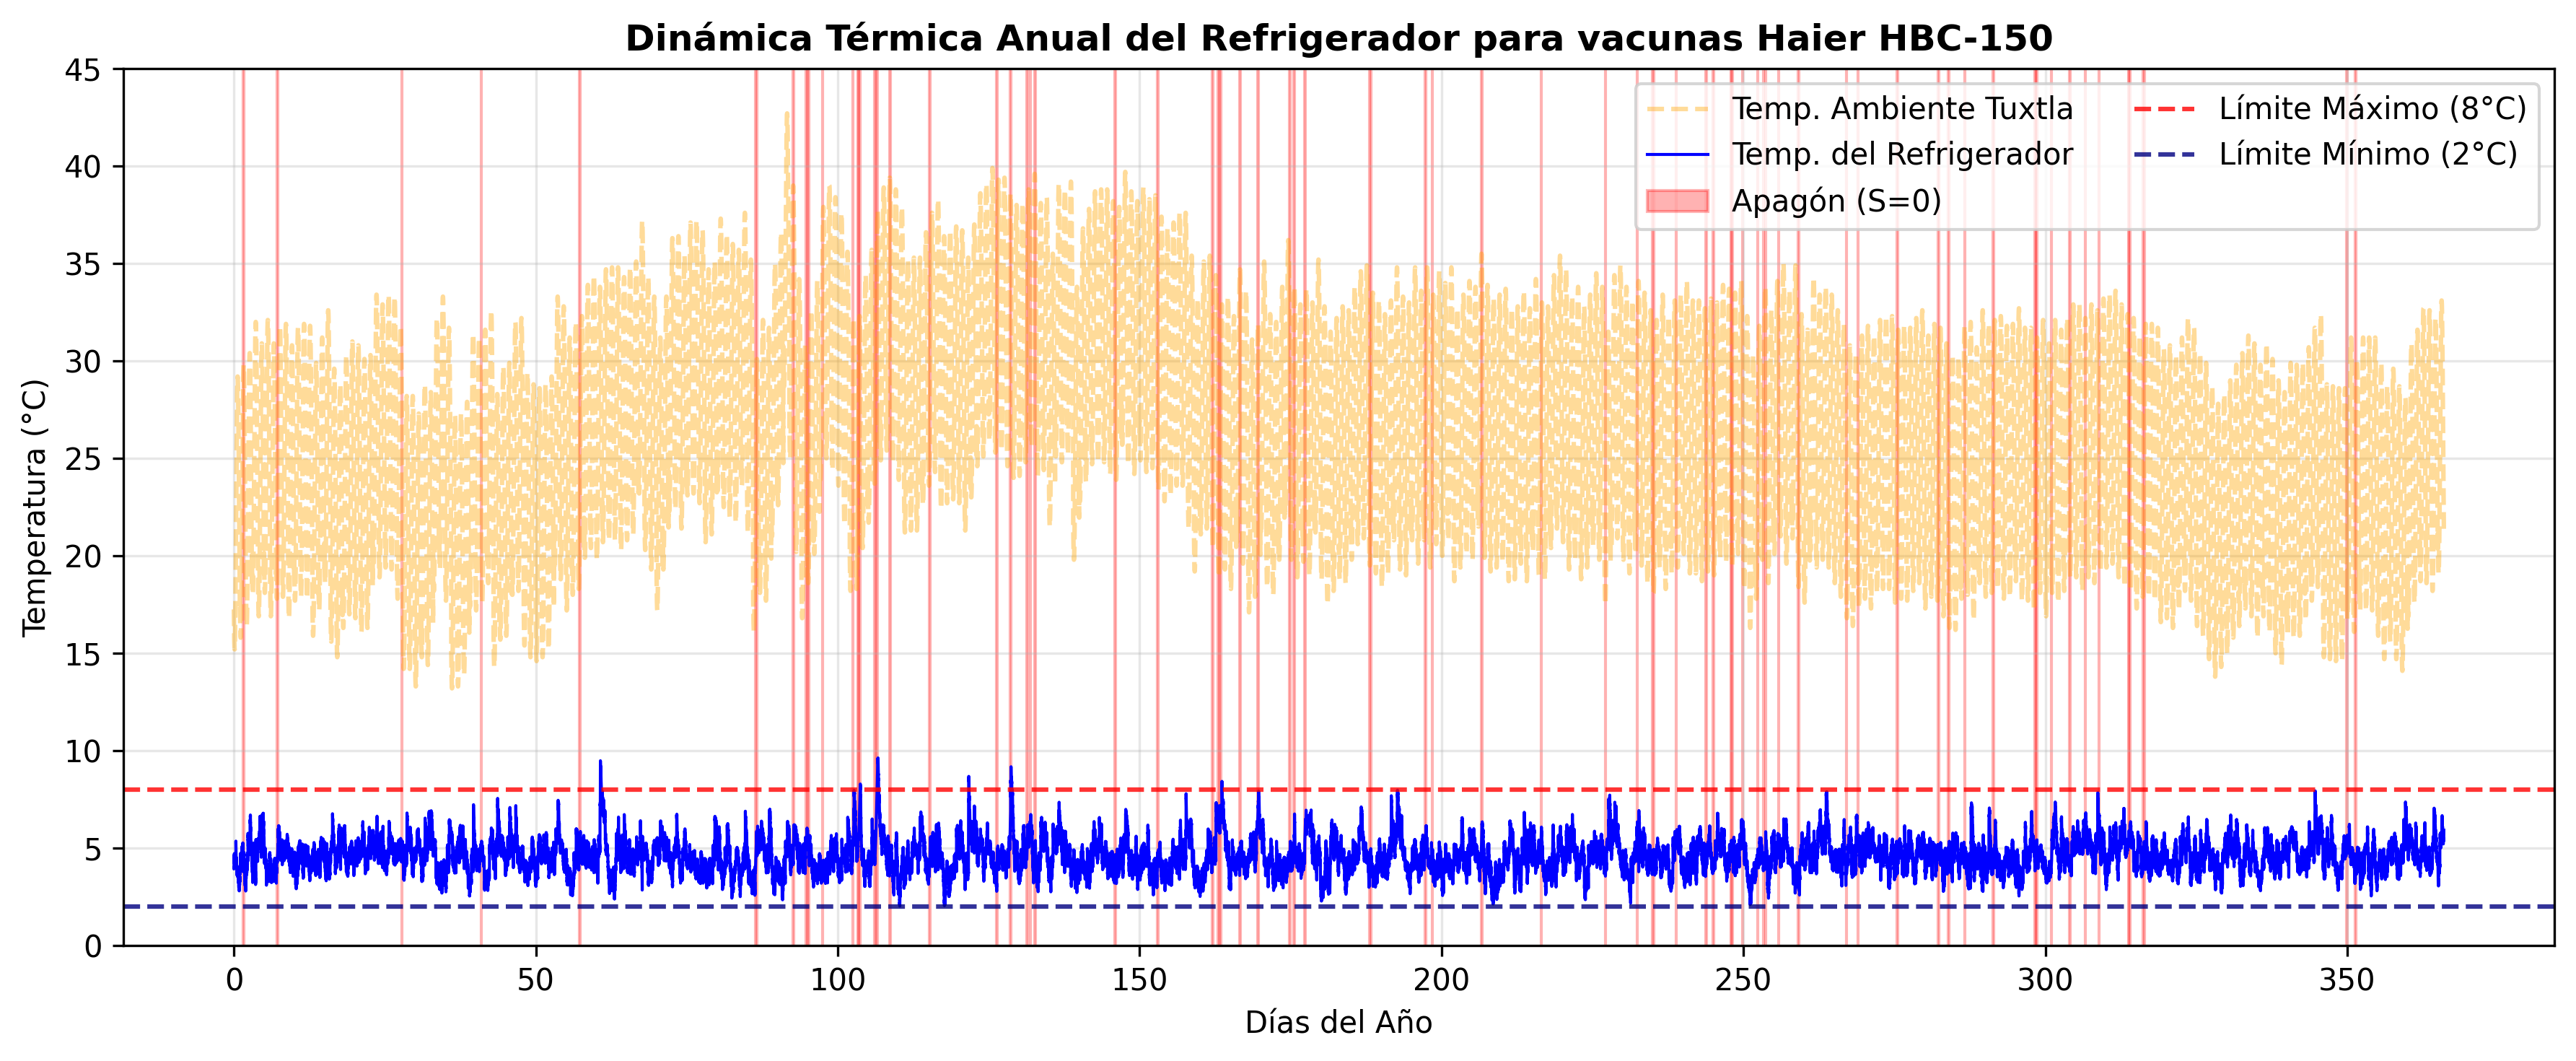

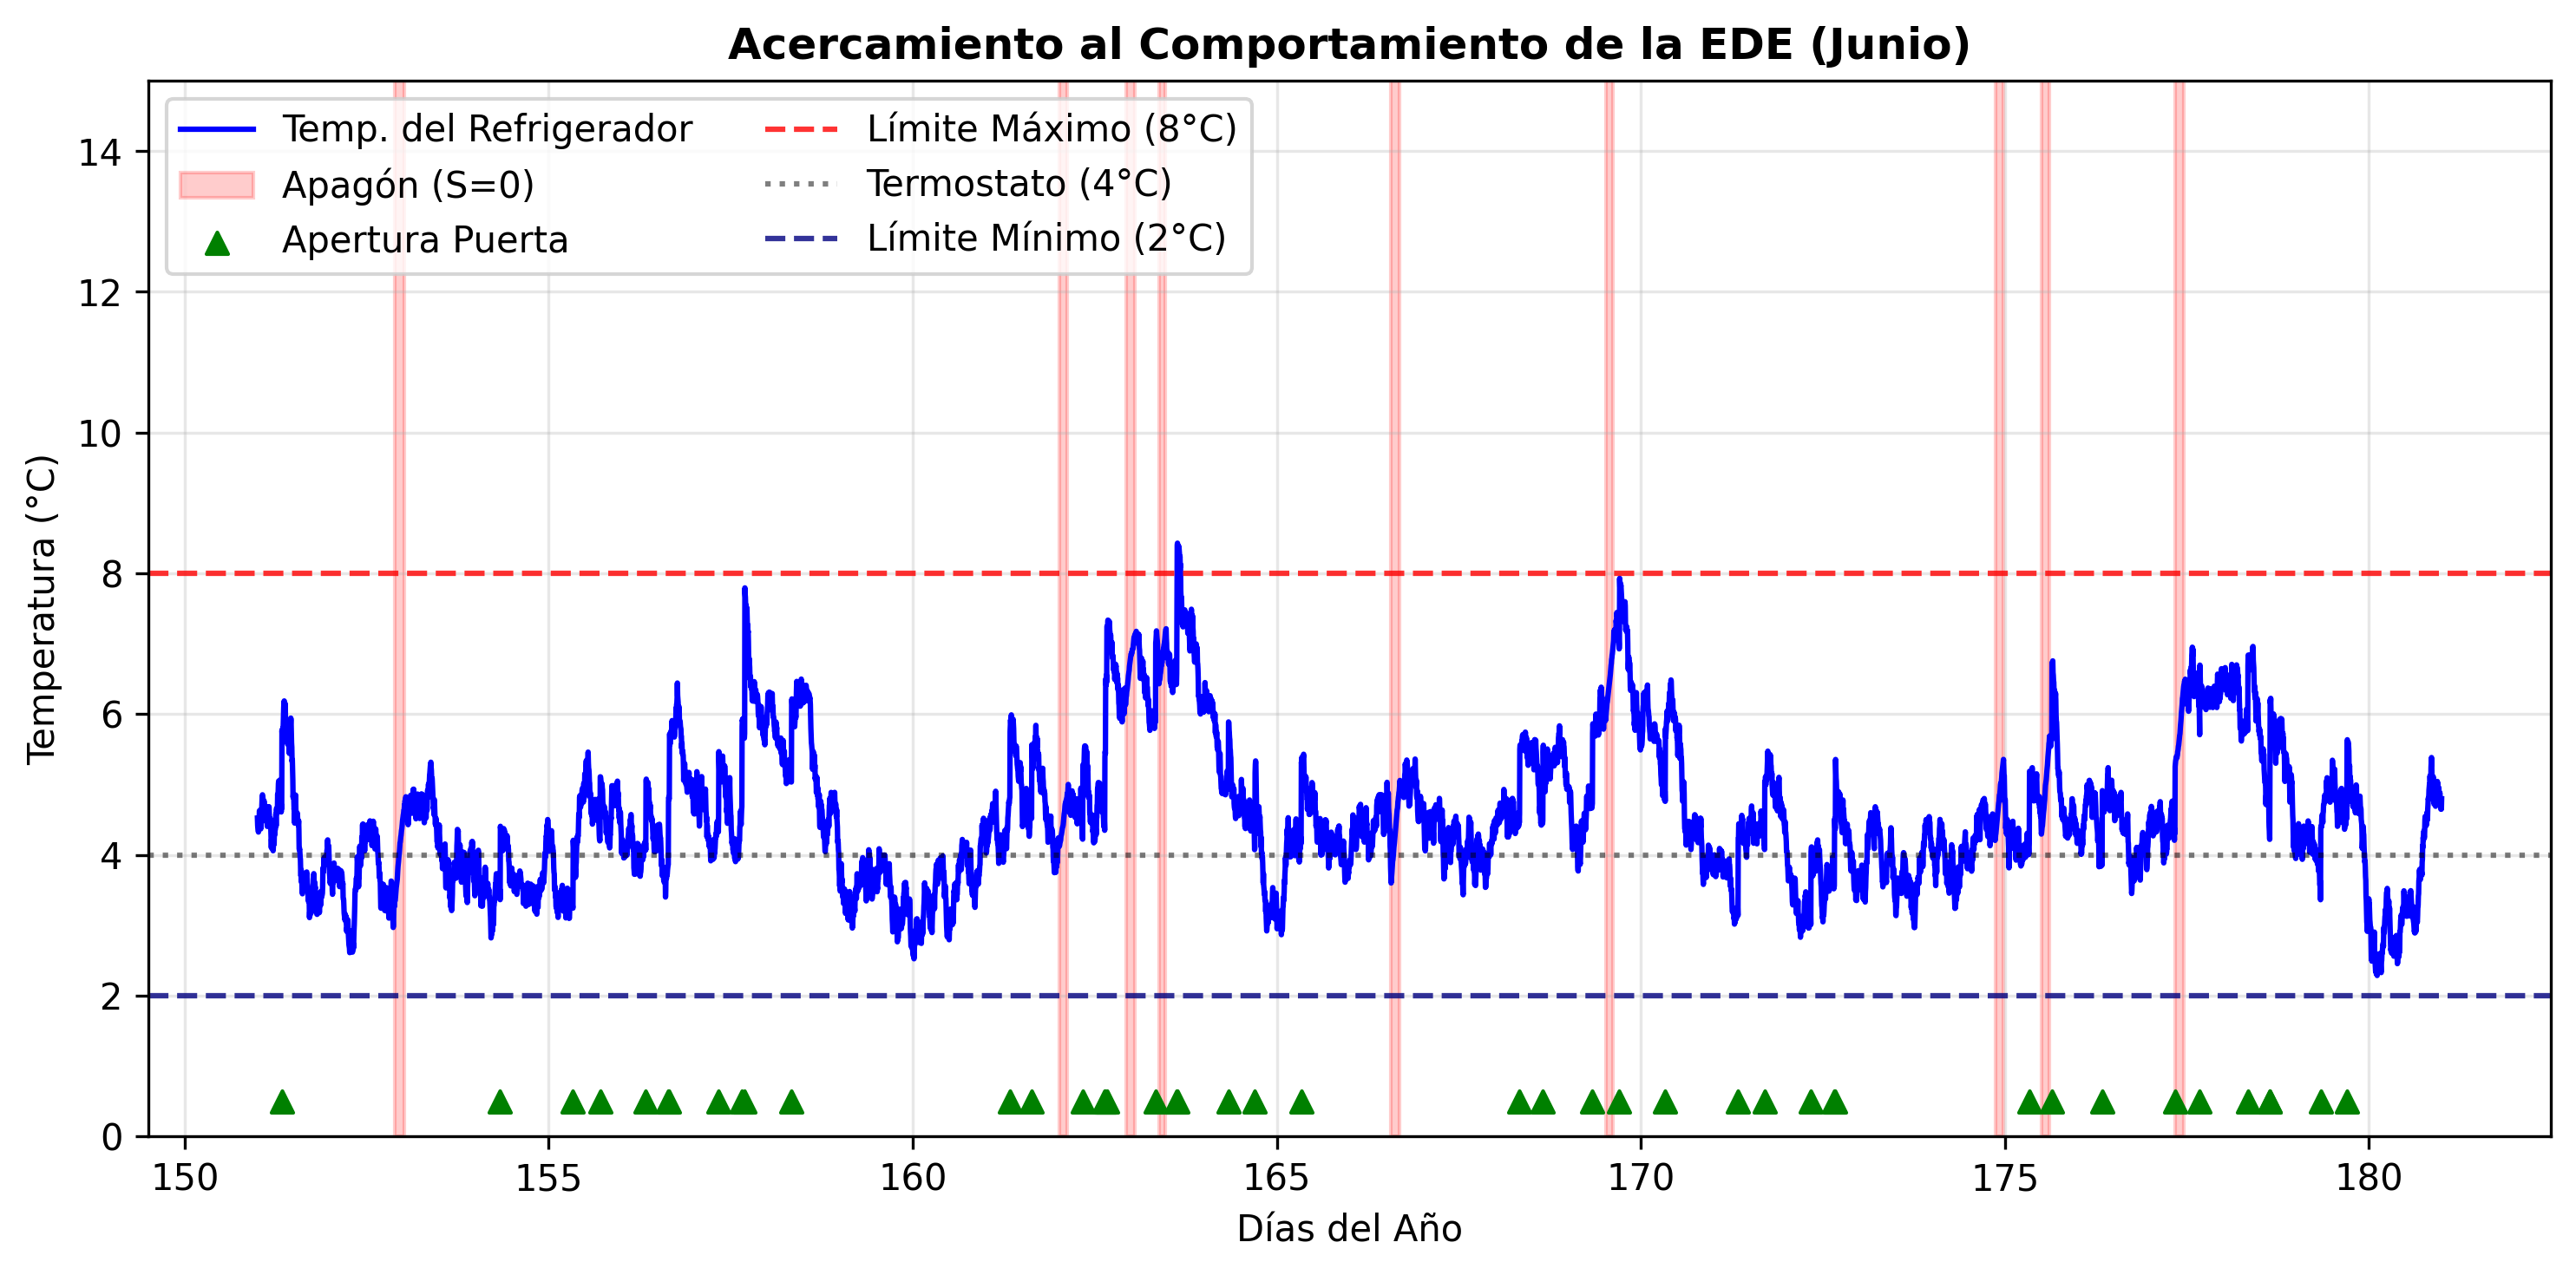

In [ ]:
# 1. PREPARACIÓN DE VECTORES PARA LA INTEGRACIÓN
np.random.seed(13) # Fijamos semilla para que el reporte sea reproducible
X_t = np.zeros(len(t_horas))
X_t[0] = T_0                # Iniciamos en 4°C
V_t = np.ones(len(t_horas)) # La viabilidad de la vacuna arranca al 100% (1.0)

print("Integrando la SDE con Euler-Maruyama y calculando Arrhenius...")

# 2. BUCLE DE INTEGRACIÓN NUMÉRICA
for i in range(1, len(t_horas)):
    # Incremento del Movimiento Browniano (Ruido blanco)
    dW = np.sqrt(dt) * np.random.randn()

    # Evaluamos el régimen eléctrico en el paso anterior
    if S_t[i-1] == 1:
        # Régimen 1: Hay electricidad (Compresor operando)
        drift = kappa_on * (theta_set - X_t[i-1]) * dt
        difusion = sigma_on * dW
        salto = Saltos_Termicos_t[i-1]
    else:
        # Régimen 2: Apagón (Inercia térmica)
        drift = kappa_off * (T_amb_t[i-1] - X_t[i-1]) * dt
        difusion = sigma_off * dW
        salto = 0 # Normativa: no se abren puertas sin luz

    # Aplicamos el esquema de Euler-Maruyama (Equivalente a Milstein aquí)
    X_t[i] = X_t[i-1] + drift + difusion + salto

    # 3. CÁLCULO DE DAÑO TÉRMICO (Solo si rebasa los 8°C)
    if X_t[i] > 8.0:
        T_kelvin = X_t[i] + 273.15
        k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
        V_t[i] = V_t[i-1] * np.exp(-k_t * dt)
    else:
        # Si está a salvo (<= 8°C), conserva la viabilidad que tenía
        V_t[i] = V_t[i-1]

print("Integración de la trayectoria completada exitosamente.\n")

# 4. GRÁFICAS DE LA TEMPERATURA DEL REFRIGERADOR

# --- GRÁFICA 1: Panorama Anual ---
plt.figure(figsize=(12, 5), dpi=300)

# Agregamos la Temperatura Ambiente de Tuxtla de fondo
plt.plot(t_horas/24, T_amb_t, color='orange', alpha=0.4, linestyle='--', label='Temp. Ambiente Tuxtla')
plt.plot(t_horas/24, X_t, color='blue', linewidth=1.0, label='Temp. del Refrigerador')

# Sombreamos en rojo los momentos donde no hubo luz
plt.fill_between(t_horas/24, 0, 45, where=(S_t==0), color='red', alpha=0.3, label='Apagón (S=0)')

# Límites de seguridad normativos
plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.8, label='Límite Máximo (8°C)')
plt.axhline(y=2.0, color='navy', linestyle='--', alpha=0.8, label='Límite Mínimo (2°C)')

plt.ylim(0, 45) # Eje y empieza en 0 obligatoriamente
plt.ylabel('Temperatura (°C)')
plt.xlabel('Días del Año')
plt.title('Dinámica Térmica Anual del Refrigerador para vacunas Haier HBC-150', fontweight='bold')
plt.legend(loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('sde_anual.png', dpi=300)
plt.show()


# --- GRÁFICA 2: Zoom a Junio ---
dia_zoom = 151

# Calculamos los índices para exactamente 24 horas (1 día completo)
idx_start = int(dia_zoom * 24 / dt)
idx_end = int((dia_zoom + 30) * 24 / dt)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas[idx_start:idx_end]/24, X_t[idx_start:idx_end], color='blue', linewidth=1.5, label='Temp. del Refrigerador')

# Sombreamos el apagón con la misma etiqueta
apagones_zoom = S_t[idx_start:idx_end]
plt.fill_between(t_horas[idx_start:idx_end]/24, 0, 15, where=(apagones_zoom==0), color='red', alpha=0.2, label='Apagón (S=0)')

# Marcamos las aperturas de puerta con triángulos verdes
aperturas_idx = np.where(dN_t_total[idx_start:idx_end] > 0)[0]
if len(aperturas_idx) > 0:
    plt.scatter(t_horas[idx_start + aperturas_idx]/24, np.zeros(len(aperturas_idx)) + 0.5, color='green', marker='^', zorder=5, label='Apertura Puerta')

# Límites de seguridad normativos y termostato
plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.8, label='Límite Máximo (8°C)')
plt.axhline(y=4.0, color='black', linestyle=':', alpha=0.5, label='Termostato (4°C)')
plt.axhline(y=2.0, color='navy', linestyle='--', alpha=0.8, label='Límite Mínimo (2°C)')

plt.ylim(0, 15) # Eje y empieza en 0 obligatoriamente
plt.ylabel('Temperatura (°C)')
plt.xlabel('Días del Año')
plt.title(f'Acercamiento al Comportamiento de la EDE (Junio)', fontweight='bold')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('sde_zoom.png', dpi=300)
plt.show()

## Celda 6: Análisis de Impacto Logístico (Inventario vs. Mermas)

En esta sección traducimos el daño teórico de la viabilidad de la vacuna en pérdidas absolutas de inventario físico. Para ello creamos dos modelos:

1. **Modelo Logístico (Inventario $I_t$):** Simulamos el consumo diario de vacunas en la clínica descontando los fines de semana. La demanda varía por mes (teniendo un pico fuerte en octubre y noviembre por la campaña de Influenza). Cuando el inventario cae al punto de reorden (20%), simulamos la llegada del camión jurisdiccional que vuelve a llenar el refrigerador a su capacidad máxima de 5,000 dosis.
2. **Cálculo de Dosis Perdidas:** En cada paso de tiempo, calculamos qué porcentaje de viabilidad se perdió con la ecuación de Arrhenius. Ese porcentaje se multiplica por las vacunas exactas que había en el refrigerador en ese instante. Acumulamos estas mermas para saber cuántas vacunas se destruyeron en total durante todo el año.
3. **Visualización:** Generamos una gráfica de doble eje. En el lado izquierdo vemos los "dientes de sierra" del consumo y reabastecimiento. En el lado derecho vemos cómo crece la curva de dosis destruidas cada vez que ocurre un apagón severo.

Total de vacunas que ingresaron a la clínica en el año: 29362 dosis.
Total de vacunas destruidas: 991 dosis.
Porcentaje de pérdida: 3.38%



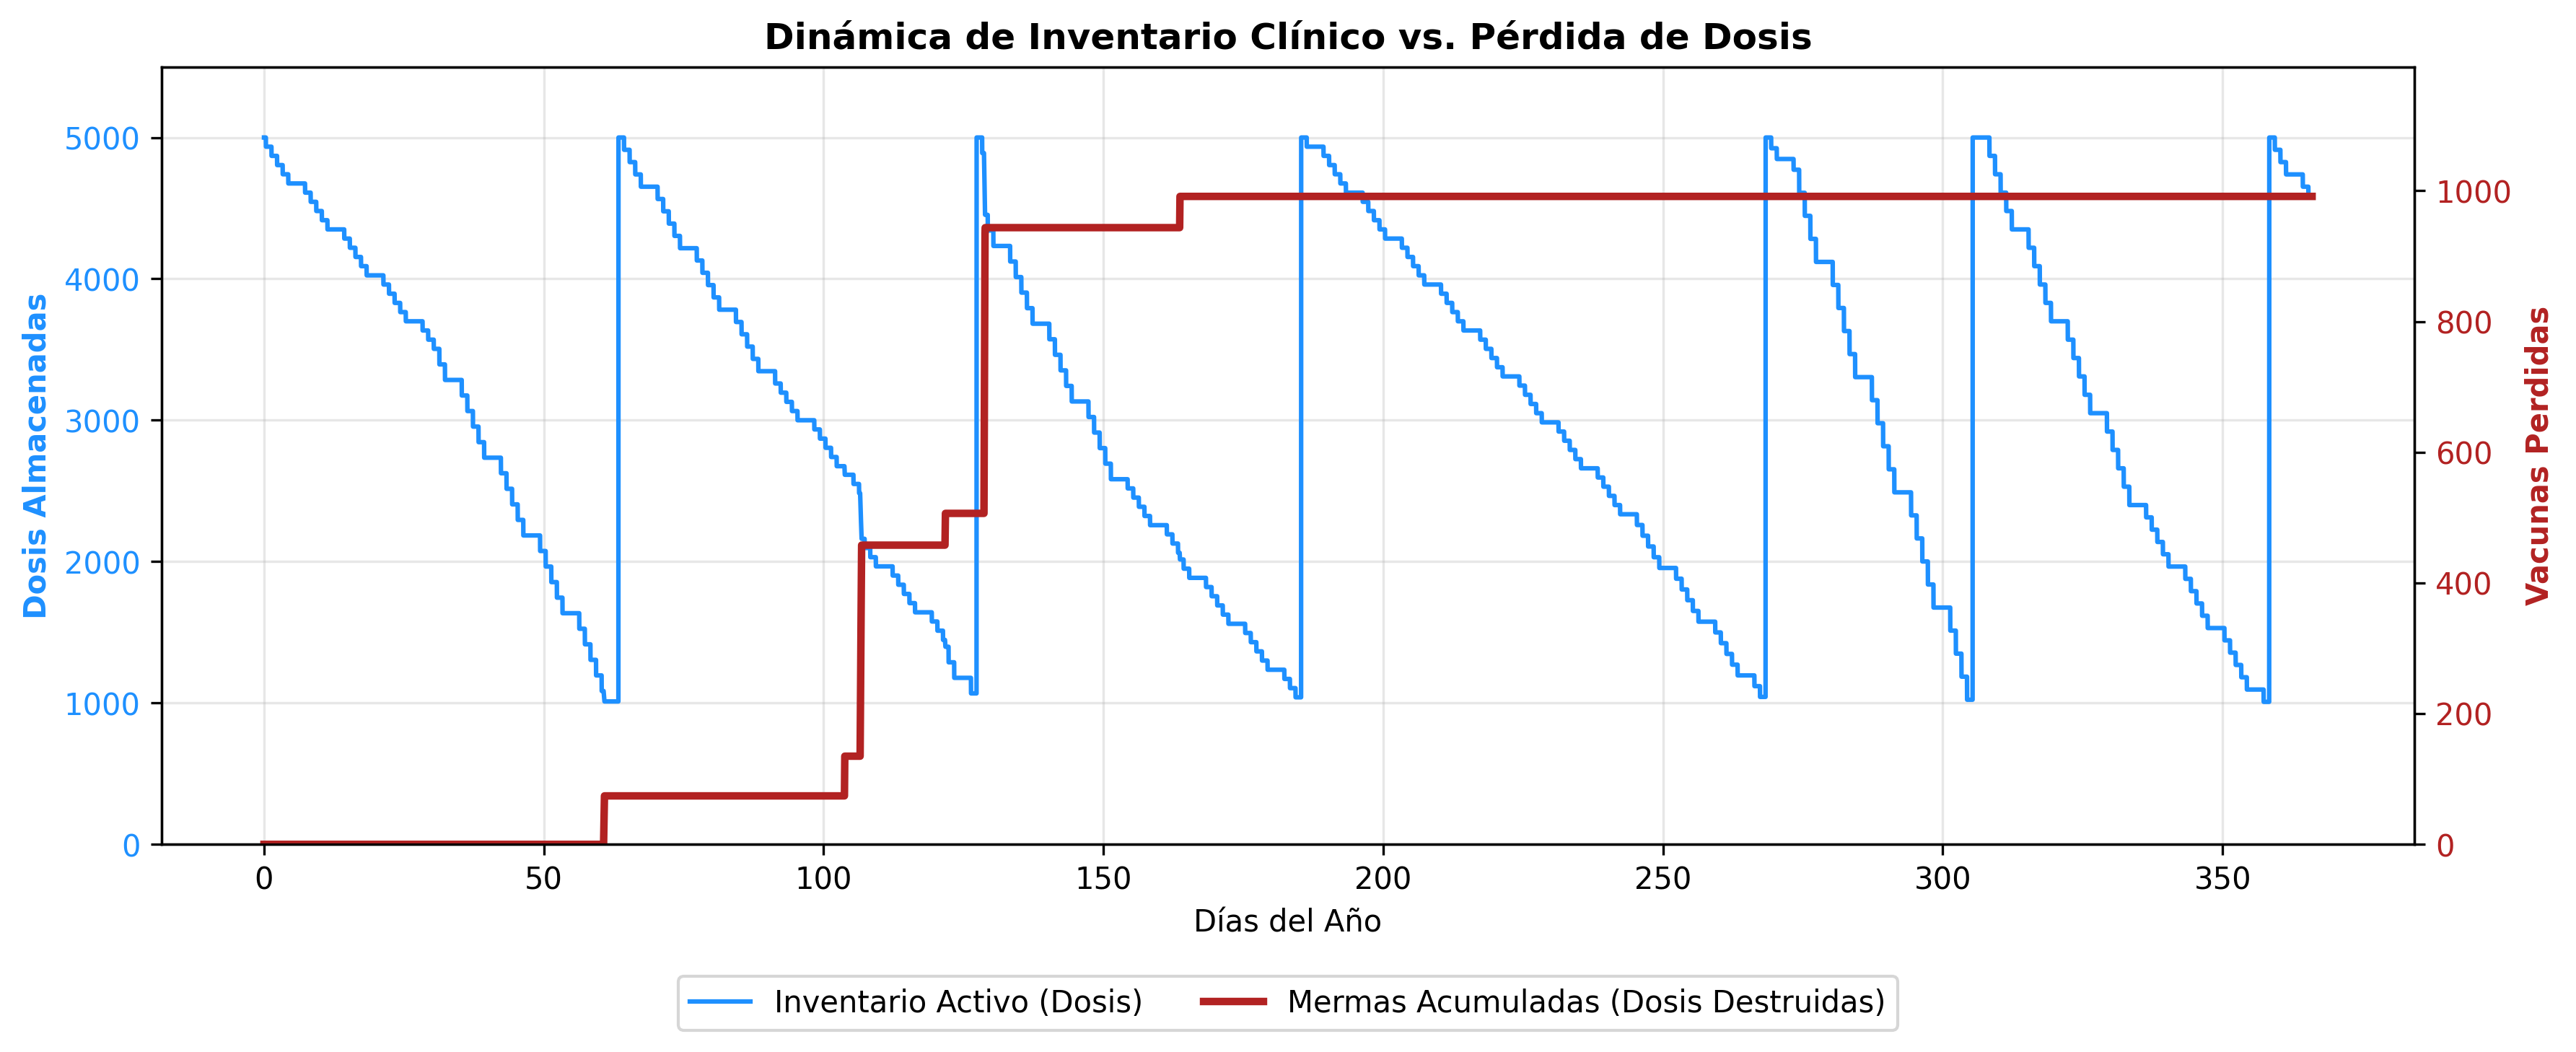

In [ ]:
# 1. PARÁMETROS DEL INVENTARIO LOGÍSTICO Y ARRHENIUS
capacidad_maxima = 5000.0  # Dosis máximas en el volumen útil del Haier HBC-150
punto_reorden = 1000.0     # Stock de seguridad (20%). Si baja de esto, se reabastece.

# Consumo diario (Lunes a Viernes) estimado por mes (Ene a Dic)
consumo_diario_mes = [65, 110, 87, 65, 110, 65, 65, 65, 76, 163, 130, 87]

R_gas = 8.314
Ea = 85000.0        # Energía de activación
A_factor = 1.2e14   # Factor de Arrhenius

I_t = np.zeros(len(t_horas))
dosis_perdidas_dt = np.zeros(len(t_horas))

I_t[0] = capacidad_maxima
total_dosis_ingresadas = capacidad_maxima # Llevamos la cuenta de todo lo que entra al refri en el año

# 2. BUCLE DINÁMICO: CONSUMO + MERMAS + REABASTECIMIENTO
steps_por_dia = int(24 / dt)
step_8am = int(8 / dt)

for i in range(1, len(t_horas)):
    # Arrastramos el inventario del paso anterior
    inventario_actual = I_t[i-1]

    # A. Consumo de vacunas a las 8:00 AM
    # Si el reloj marca exactamente las 8 AM, aplicamos el consumo del día
    if i % steps_por_dia == step_8am:
        dia = i // steps_por_dia
        if dia < len(es_finde_diario) and not es_finde_diario[dia]:
            mes_actual = min(int((dia % 365) / 30.416), 11)
            inventario_actual -= consumo_diario_mes[mes_actual]

    # B. Daño Térmico (Merma) en este preciso paso de 5 minutos
    if X_t[i] > 8.0:
        T_kelvin = X_t[i] + 273.15
        k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
        fraccion_perdida = 1 - np.exp(-k_t * dt)
        merma_instante = inventario_actual * fraccion_perdida
    else:
        merma_instante = 0.0

    dosis_perdidas_dt[i] = merma_instante
    inventario_actual -= merma_instante # RESTAMOS LAS VACUNAS ECHADAS A PERDER

    # C. Reabastecimiento automático si cruzamos el límite de riesgo
    if inventario_actual <= punto_reorden:
        dosis_a_pedir = capacidad_maxima - inventario_actual
        total_dosis_ingresadas += dosis_a_pedir
        inventario_actual = capacidad_maxima # Se llena el refri

    I_t[i] = inventario_actual

# 3. RESULTADOS NUMÉRICOS
merma_acumulada_t = np.cumsum(dosis_perdidas_dt)
porcentaje_perdida = (merma_acumulada_t[-1] / total_dosis_ingresadas) * 100

print(f"Total de vacunas que ingresaron a la clínica en el año: {total_dosis_ingresadas:.0f} dosis.")
print(f"Total de vacunas destruidas: {merma_acumulada_t[-1]:.0f} dosis.")
print(f"Porcentaje de pérdida: {porcentaje_perdida:.2f}%\n")

# 4. VISUALIZACIÓN LOGÍSTICA (INVENTARIO VS PÉRDIDAS)
plt.figure(figsize=(12, 5), dpi=300)

# Eje principal (Izquierdo) para el Inventario
ax1 = plt.gca()
ax1.plot(t_horas/24, I_t, label='Inventario Activo (Dosis)', color='dodgerblue', linewidth=1.5)
ax1.set_xlabel('Días del Año')
ax1.set_ylabel('Dosis Almacenadas', color='dodgerblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_ylim(0, capacidad_maxima * 1.1)

# Eje secundario (Derecho) para las Mermas
ax2 = ax1.twinx()
ax2.plot(t_horas/24, merma_acumulada_t, label='Mermas Acumuladas (Dosis Destruidas)', color='firebrick', linewidth=2.5)
ax2.set_ylabel('Vacunas Perdidas', color='firebrick', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='firebrick')

max_merma_plot = np.max(merma_acumulada_t)
if max_merma_plot > 0:
    ax2.set_ylim(0, max_merma_plot * 1.2)
else:
    ax2.set_ylim(0, 10)

plt.title('Dinámica de Inventario Clínico vs. Pérdida de Dosis', fontweight='bold', fontsize=12)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('inventario_vs_mermas.png', dpi=300)
plt.show()

## Celda 7: Simulación de Montecarlo (Motor Estocástico)

En esta sección consolidamos nuestras tres dinámicas (térmica, eléctrica y logística) dentro de una única función maestra llamada `simular_un_ano()`. El objetivo de esta función es generar una trayectoria completa de 365 días en cuestión de segundos.

Para no depender de un solo escenario fortuito, aplicaremos el algoritmo de **Montecarlo**. Ejecutaremos esta función múltiples veces independientes (cambiando la semilla aleatoria en cada iteración) para generar una muestra estadística robusta de "años posibles". Esto nos permitirá aplicar la Ley de los Grandes Números y extraer promedios de riesgo reales, métricas de confiabilidad y promedios esperados de destrucción de biológicos.

In [ ]:
import time

# 1. FUNCIÓN PRINCIPAL DE SIMULACIÓN ANUAL
def simular_un_ano(semilla):
    """Ejecuta un año completo de simulación y devuelve las métricas clave."""
    np.random.seed(semilla)

    # Inicialización de Vectores
    S_t = np.ones(len(t_horas))
    I_t = np.zeros(len(t_horas))
    dosis_perdidas_dt = np.zeros(len(t_horas))
    merma_por_mes = np.zeros(12) # Array para guardar la merma de cada mes

    dias_totales = int(np.ceil(t_horas[-1] / 24))
    inventario_actual = capacidad_maxima
    total_dosis_ingresadas = capacidad_maxima

    # Generación de Apagones
    for dia in range(dias_totales):
        tasa_hoy = tasa_cortes_cfe(dia)
        num_cortes = np.random.poisson(tasa_hoy)

        for _ in range(num_cortes):
            hora_inicio = (dia * 24) + np.random.uniform(0, 24)
            mu_ln, sigma_ln = obtener_parametros_lognormal(dia)
            duracion_horas = np.random.lognormal(mu_ln, sigma_ln)

            idx_inicio = int(hora_inicio / dt)
            idx_fin = int((hora_inicio + duracion_horas) / dt)

            if idx_inicio < len(S_t):
                idx_fin = min(idx_fin, len(S_t))
                S_t[idx_inicio:idx_fin] = 0

    # Generación de Aperturas de Puerta
    esperados_tarde = lambda_puerta * dt
    dN_t_tarde = np.random.poisson(esperados_tarde)
    dN_t_manana = apertura_manana_fija.astype(int)

    dN_t_total = (dN_t_tarde + dN_t_manana) * S_t
    Saltos_Termicos_t = dN_t_total * gamma_salto # gamma_salto = 1.0

    # Integración de la SDE y Modelo Logístico
    X_t = np.zeros(len(t_horas))
    X_t[0] = T_0

    dW_vec = np.sqrt(dt) * np.random.randn(len(t_horas))
    steps_por_dia = int(24 / dt)
    step_8am = int(8 / dt)

    for i in range(1, len(t_horas)):
        # SDE Numérica
        if S_t[i-1] == 1:
            drift = kappa_on * (theta_set - X_t[i-1]) * dt
            difusion = sigma_on * dW_vec[i]
            salto = Saltos_Termicos_t[i-1]
        else:
            drift = kappa_off * (T_amb_t[i-1] - X_t[i-1]) * dt
            difusion = sigma_off * dW_vec[i]
            salto = 0

        X_t[i] = X_t[i-1] + drift + difusion + salto

        # Obtenemos el mes actual para los registros
        dia_actual = i // steps_por_dia
        mes_actual = min(int((dia_actual % 365) / 30.416), 11)

        # Lógica de Consumo Logístico a las 8 AM
        if i % steps_por_dia == step_8am:
            if dia_actual < len(es_finde_diario) and not es_finde_diario[dia_actual]:
                inventario_actual -= consumo_diario_mes[mes_actual]

        # Ecuación de Arrhenius y Mermas
        if X_t[i] > 8.0:
            T_kelvin = X_t[i] + 273.15
            k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
            fraccion_perdida = 1 - np.exp(-k_t * dt)
            merma_instante = inventario_actual * fraccion_perdida
        else:
            merma_instante = 0.0

        dosis_perdidas_dt[i] = merma_instante
        inventario_actual -= merma_instante

        # Guardamos la merma en la casilla del mes correspondiente
        merma_por_mes[mes_actual] += merma_instante

        # Reabastecimiento Automático
        if inventario_actual <= punto_reorden:
            total_dosis_ingresadas += (capacidad_maxima - inventario_actual)
            inventario_actual = capacidad_maxima

        I_t[i] = inventario_actual

    # Extracción de Métricas y Retorno
    return {
        'merma_anual': np.sum(dosis_perdidas_dt),
        'dosis_totales_ingresadas': total_dosis_ingresadas,
        'total_apagones': np.sum(np.diff(S_t) == -1),
        'total_aperturas': np.sum(dN_t_total),
        'merma_por_mes': merma_por_mes,
        'trayectoria_merma': np.cumsum(dosis_perdidas_dt)
    }

# 2. EJECUCIÓN DEL BUCLE DE MONTECARLO

N_SIMULACIONES = 1000
resultados_mc = []

print(f"Iniciando Montecarlo con {N_SIMULACIONES} trayectorias...")
inicio_tiempo = time.time()

for sim in range(N_SIMULACIONES):
    resultado = simular_un_ano(semilla=sim + 42)
    resultados_mc.append(resultado)

    if (sim + 1) % 100 == 0:
        print(f"Progreso: {sim + 1} / {N_SIMULACIONES} años simulados.")

tiempo_total = time.time() - inicio_tiempo
print(f"¡Simulación Montecarlo completada en {tiempo_total/60:.2f} minutos!")

Iniciando Montecarlo con 1000 trayectorias...
Progreso: 100 / 1000 años simulados.
Progreso: 200 / 1000 años simulados.
Progreso: 300 / 1000 años simulados.
Progreso: 400 / 1000 años simulados.
Progreso: 500 / 1000 años simulados.
Progreso: 600 / 1000 años simulados.
Progreso: 700 / 1000 años simulados.
Progreso: 800 / 1000 años simulados.
Progreso: 900 / 1000 años simulados.
Progreso: 1000 / 1000 años simulados.
¡Simulación Montecarlo completada en 5.59 minutos!


## Celda 8: Extracción de Estadísticas y Análisis de Riesgo

Una vez completadas las simulaciones de Montecarlo, extraemos las métricas operativas y termodinámicas de todos los "años" generados para encontrar el verdadero nivel de riesgo al que está expuesto el biológico.

1. **Variables de Control:** Validamos matemáticamente que la frecuencia de apagones en la simulación promedio concuerde con los datos empíricos de la CFE (alrededor de 64 cortes) y que las aperturas de puerta respeten la norma.
2. **Abanico de Trayectorias:** Visualizamos una sub-muestra de años para observar cómo la divergencia estocástica de los apagones (sus duraciones y momentos exactos de ocurrencia) generan distintos niveles de daño acumulado.
3. **La Paradoja Estacional:** A través de un gráfico de barras, cruzamos la vulnerabilidad climática contra la saturación logística. Analizamos en qué mes se pierden más vacunas: ¿en junio (mes de mayor calor y apagones) o en octubre (mes de la campaña de Influenza con el refrigerador saturado)?
4. **Distribución del Riesgo (% de Merma):** Calculamos el porcentaje de vacunas perdidas en cada uno de los 1000 años simulados y generamos un histograma. Con esto, extraemos el Intervalo de Predicción al 95% (Percentil 2.5 y 97.5) para concluir con un nivel de certeza estricto cuál es el riesgo operativo real en Tuxtla Gutiérrez.

REPORTE ESTADÍSTICO DE LA RED DE FRÍO
Trayectorias Simuladas: 1000 años

--- Variables de Control Operativo ---
Apagones promedio: 64.0 por año
Aperturas promedio: 515 por año

--- Análisis de Riesgo (Dosis Perdidas por Refrigerador) ---
Mediana de pérdidas anuales: 751 dosis
Promedio de pérdidas anuales: 827 dosis
Riesgo Severo (Percentil 95): 1736 dosis (En el 95% de los años, no se perderan más de esto)

--- Análisis de Riesgo (Porcentaje de Merma) ---
Mediana de pérdida: 2.57%
Promedio de pérdida: 2.87%
Intervalo del 95%: Entre 0.72% y 6.57%


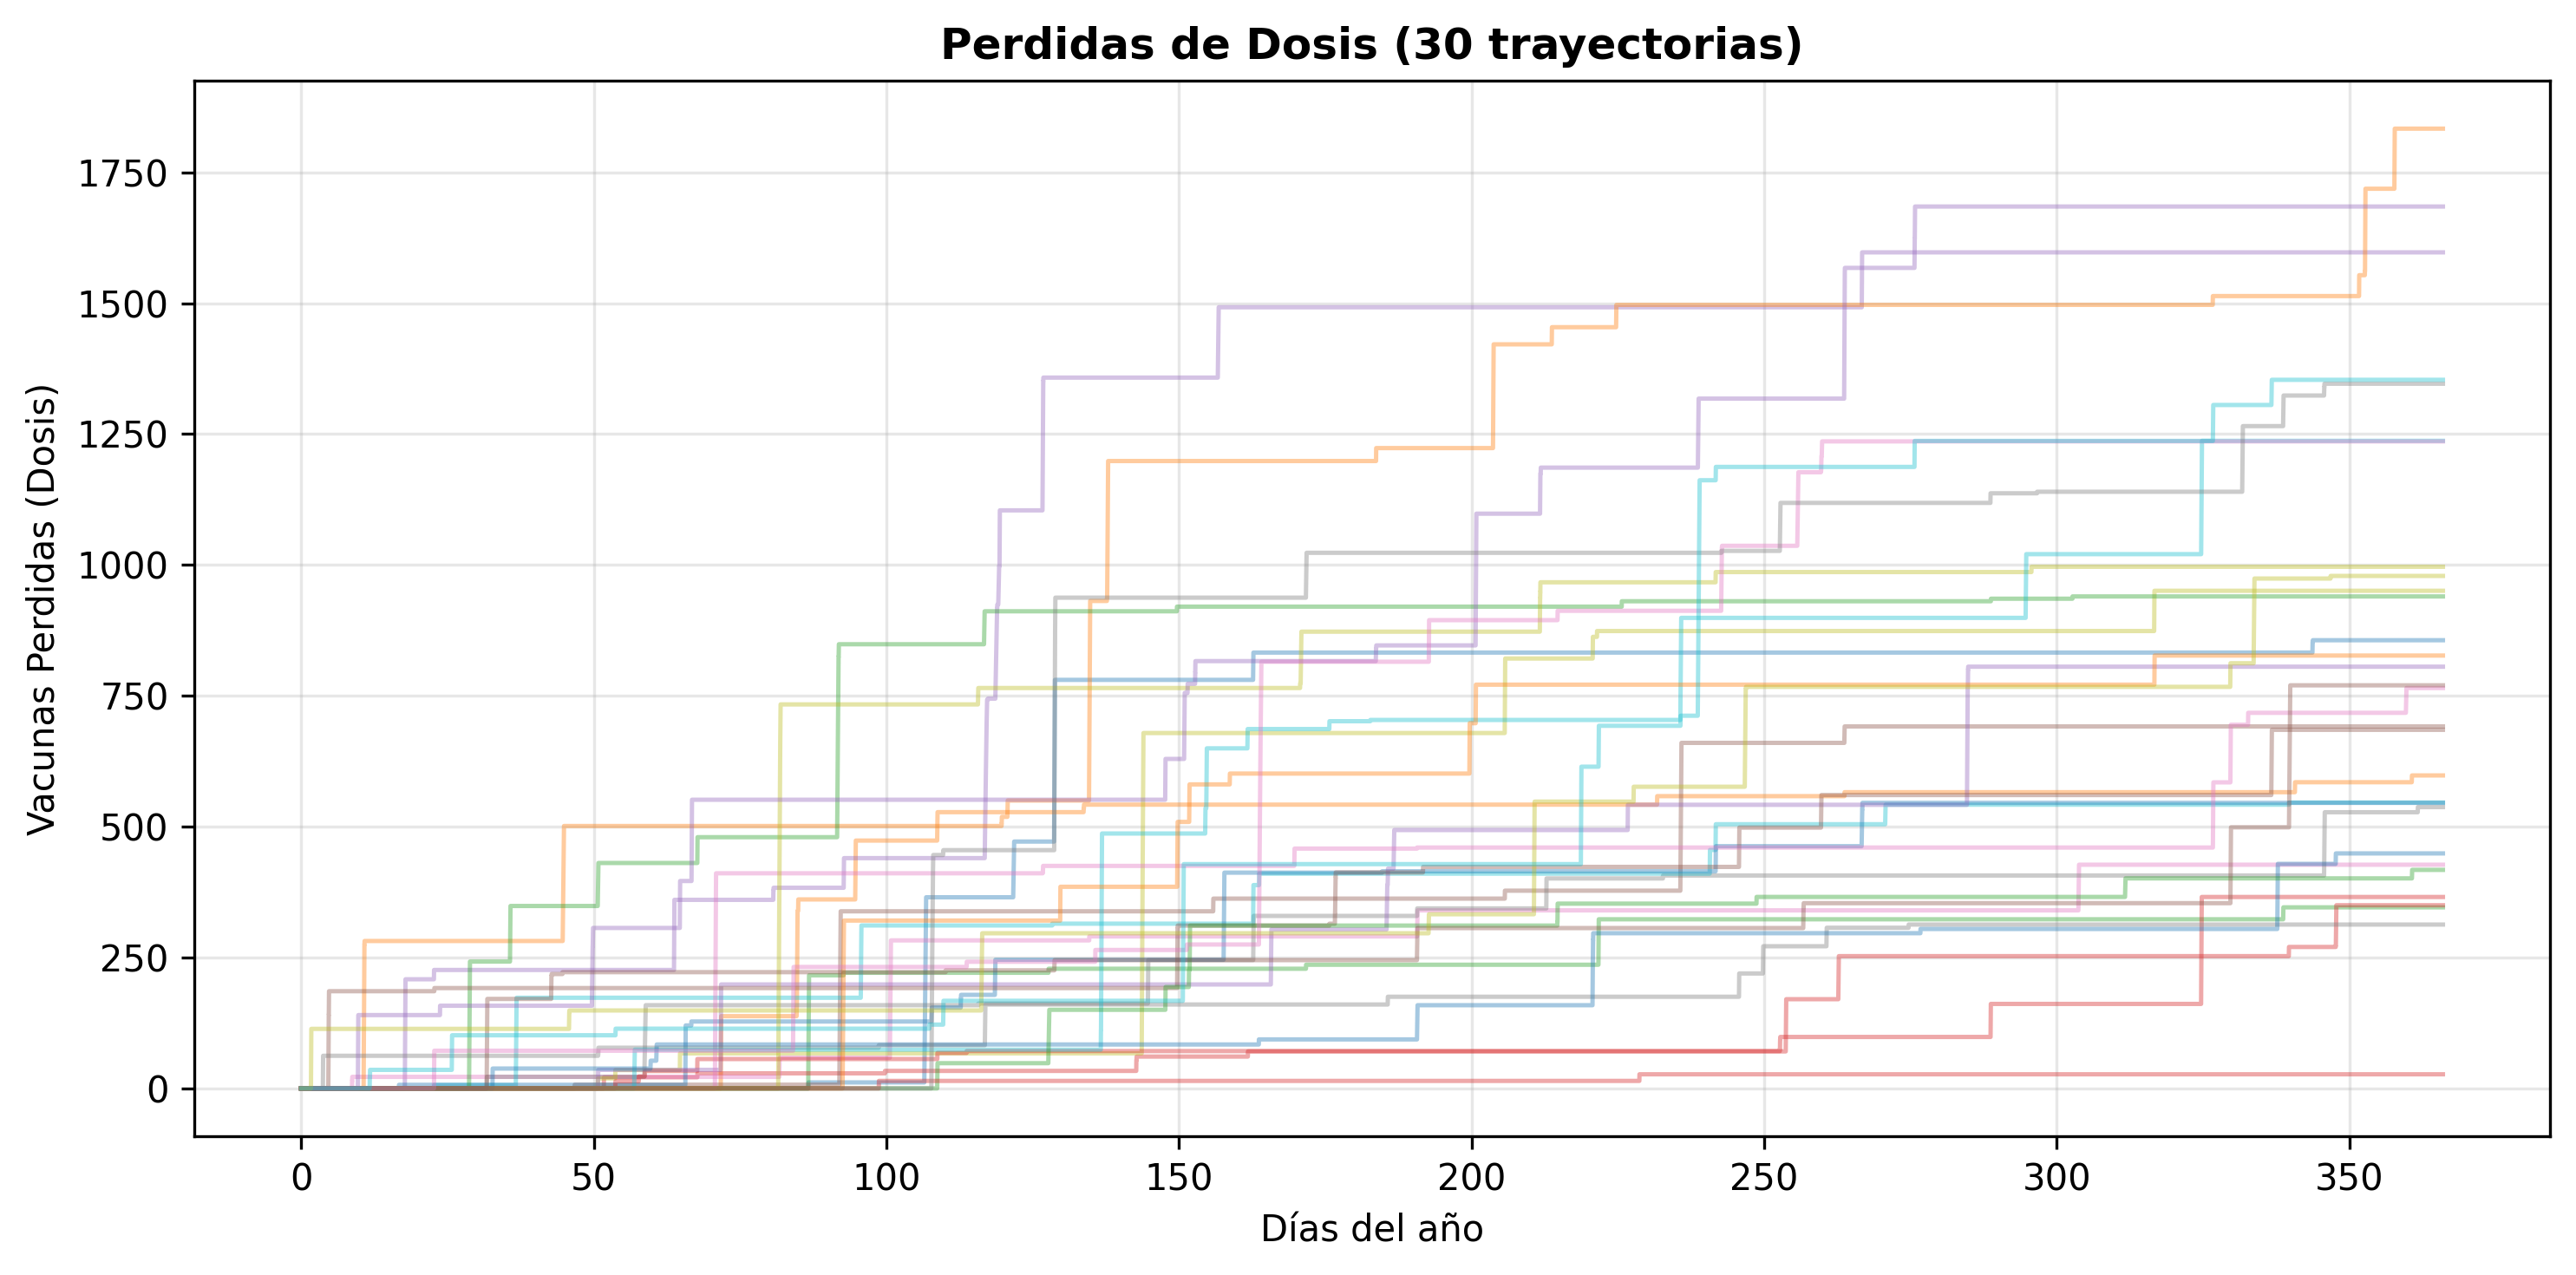

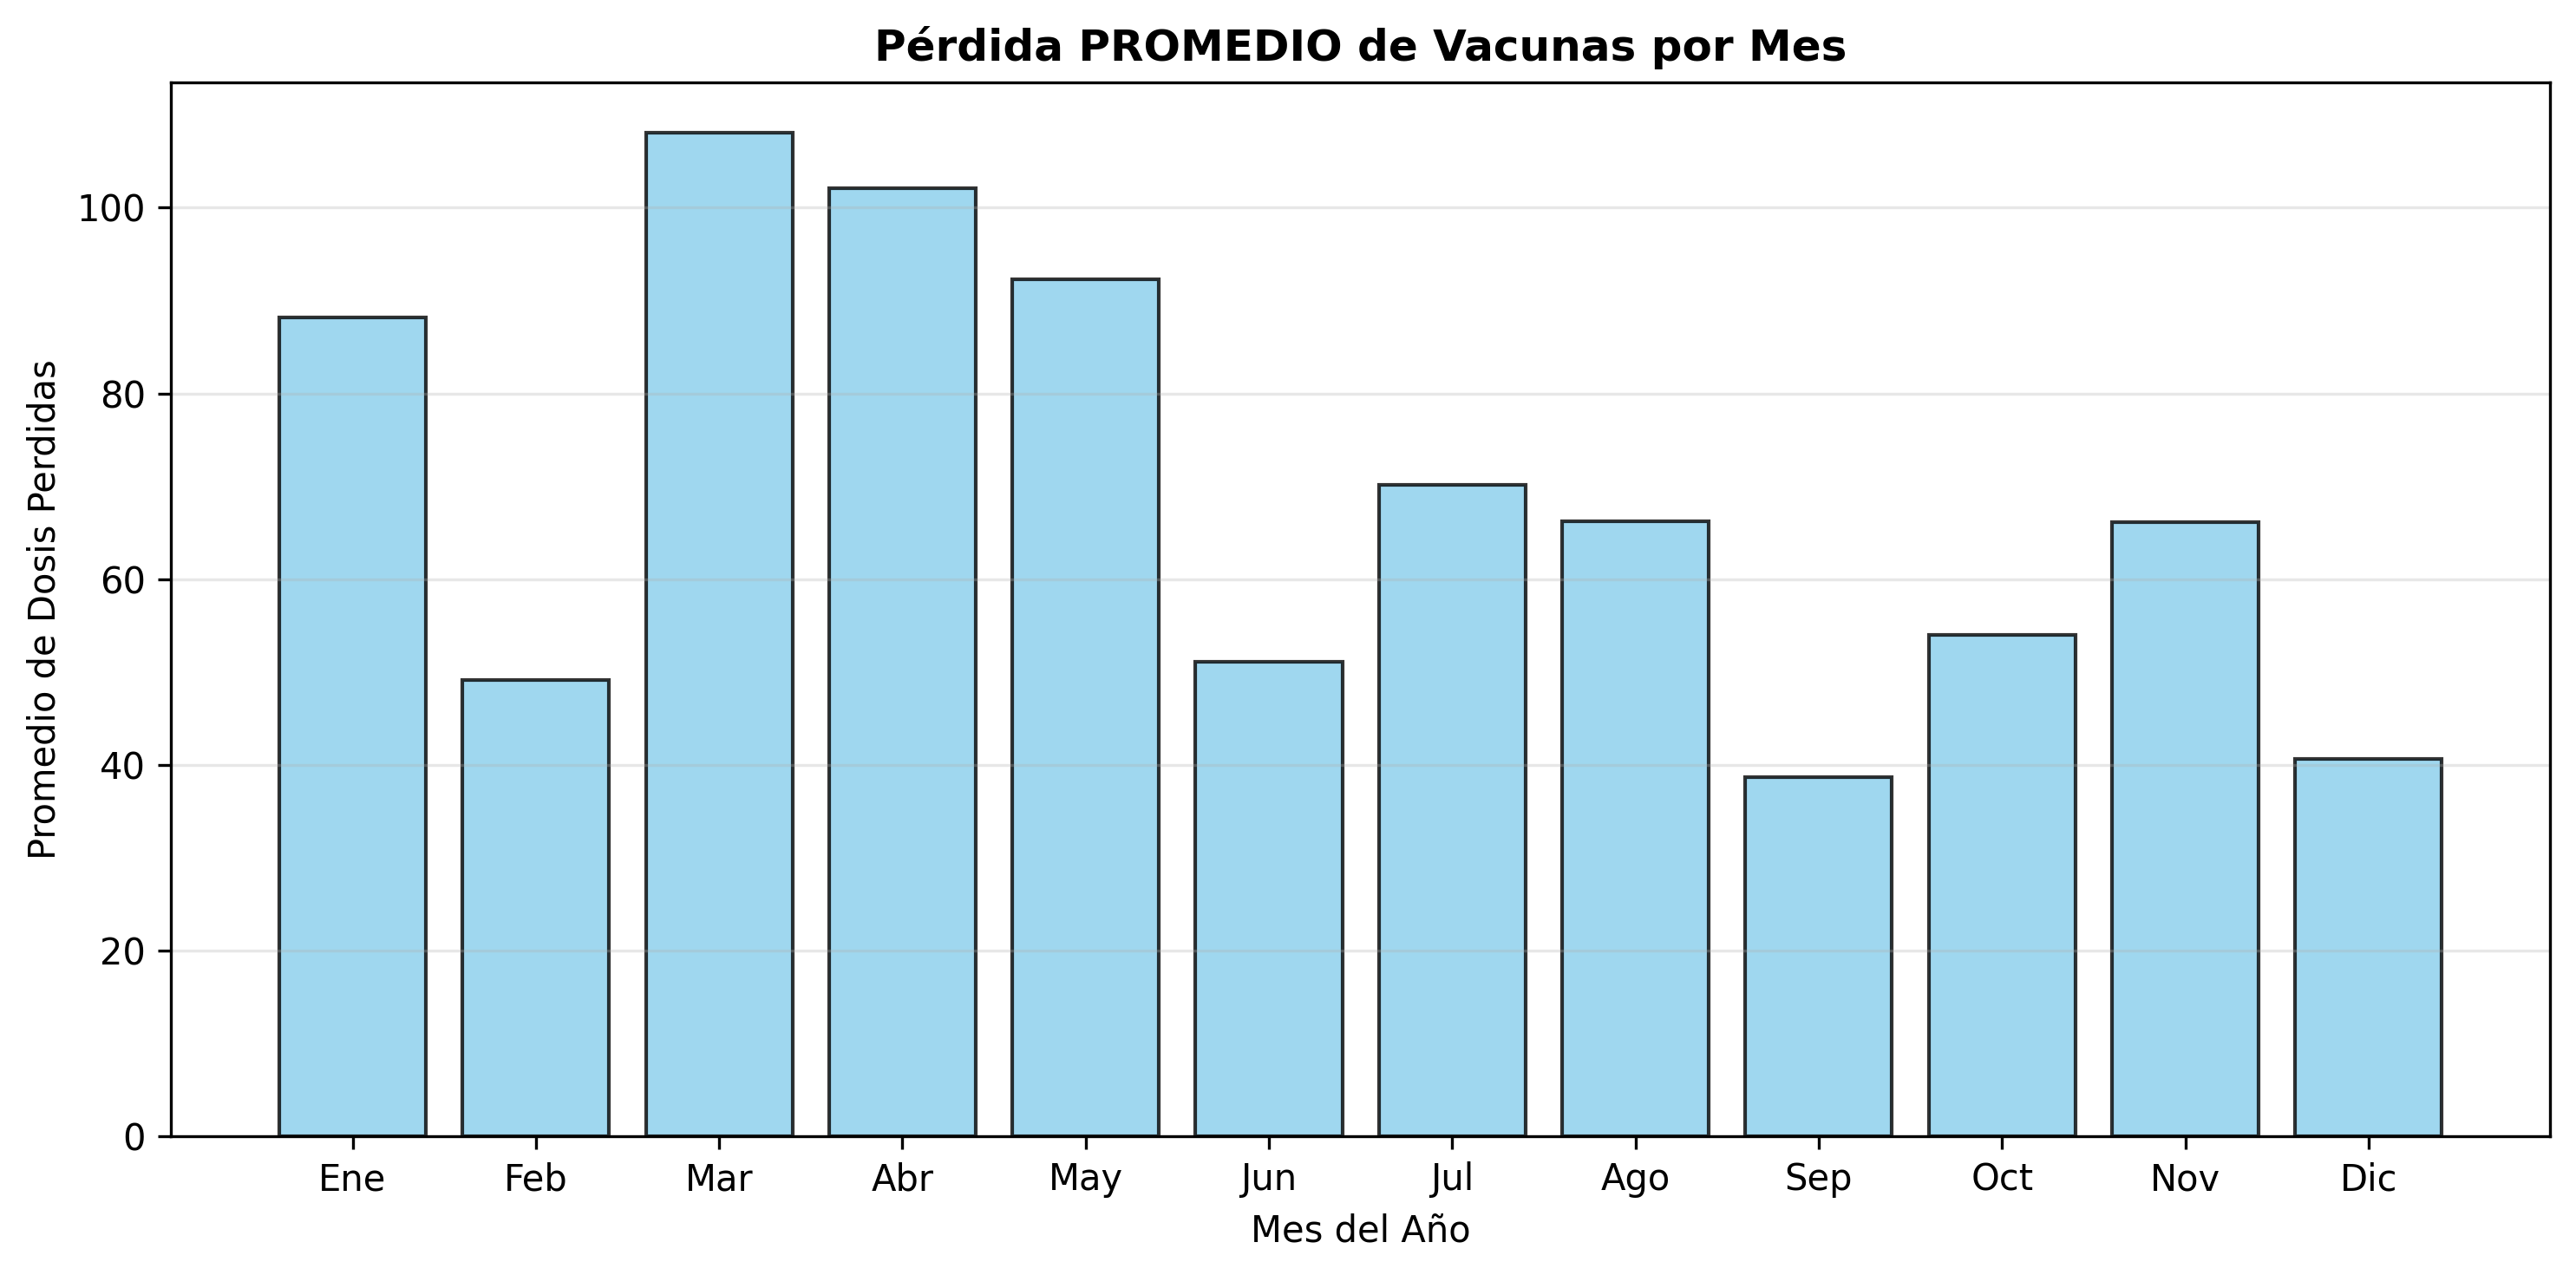

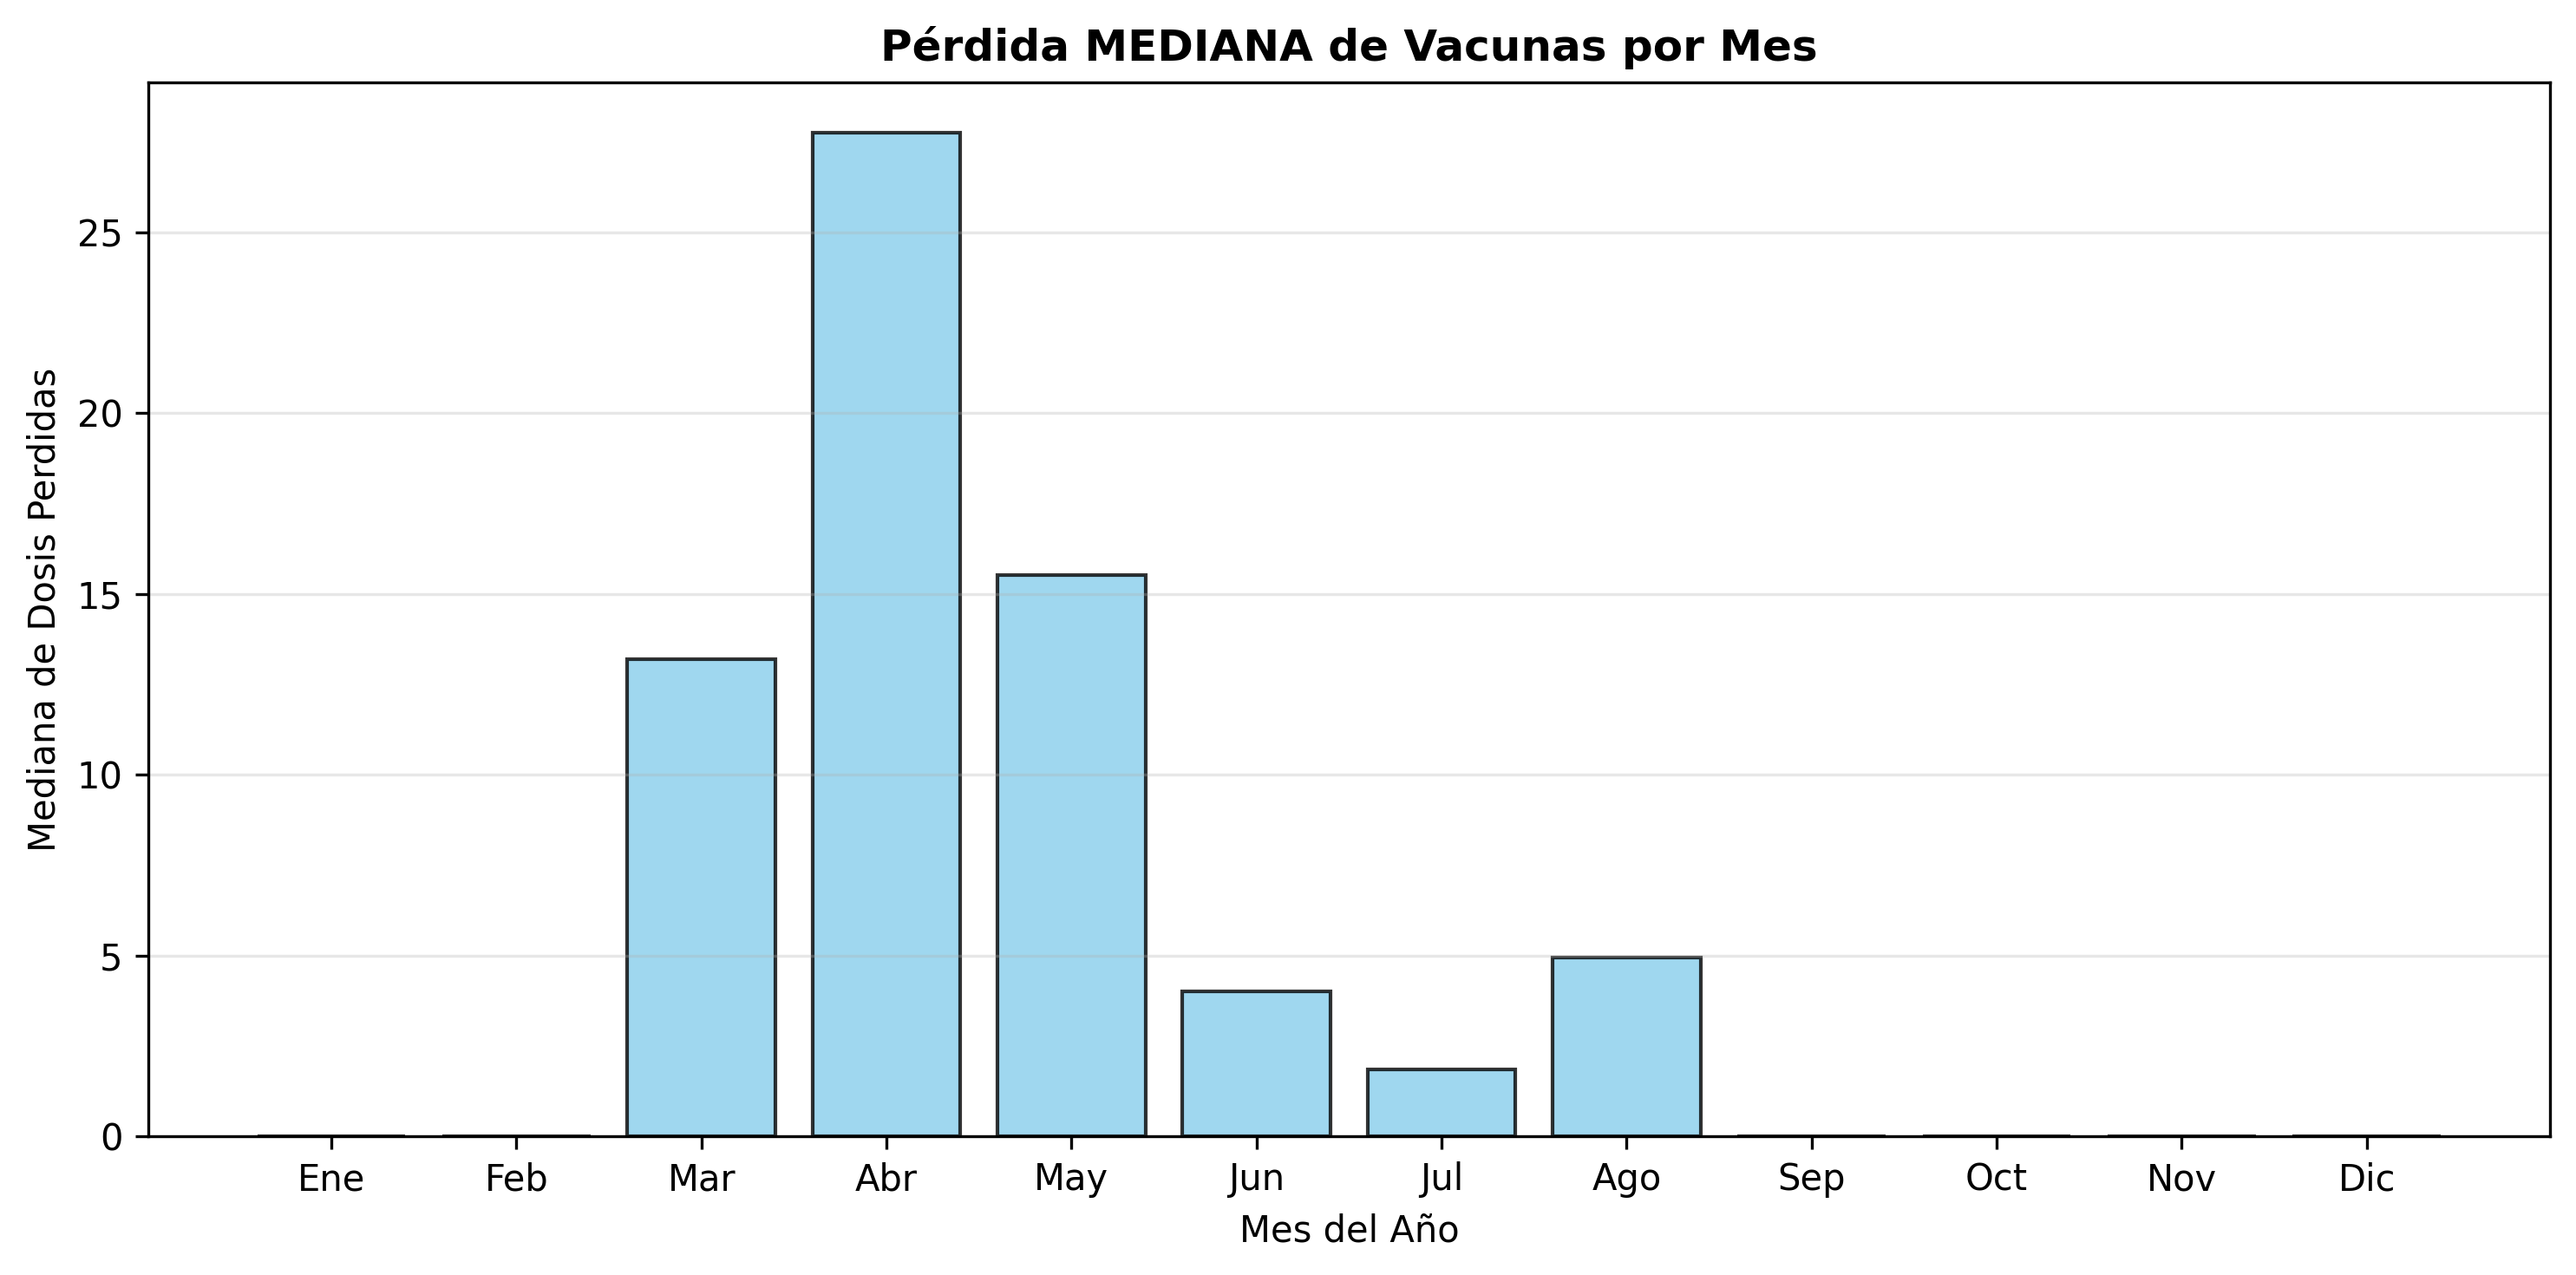

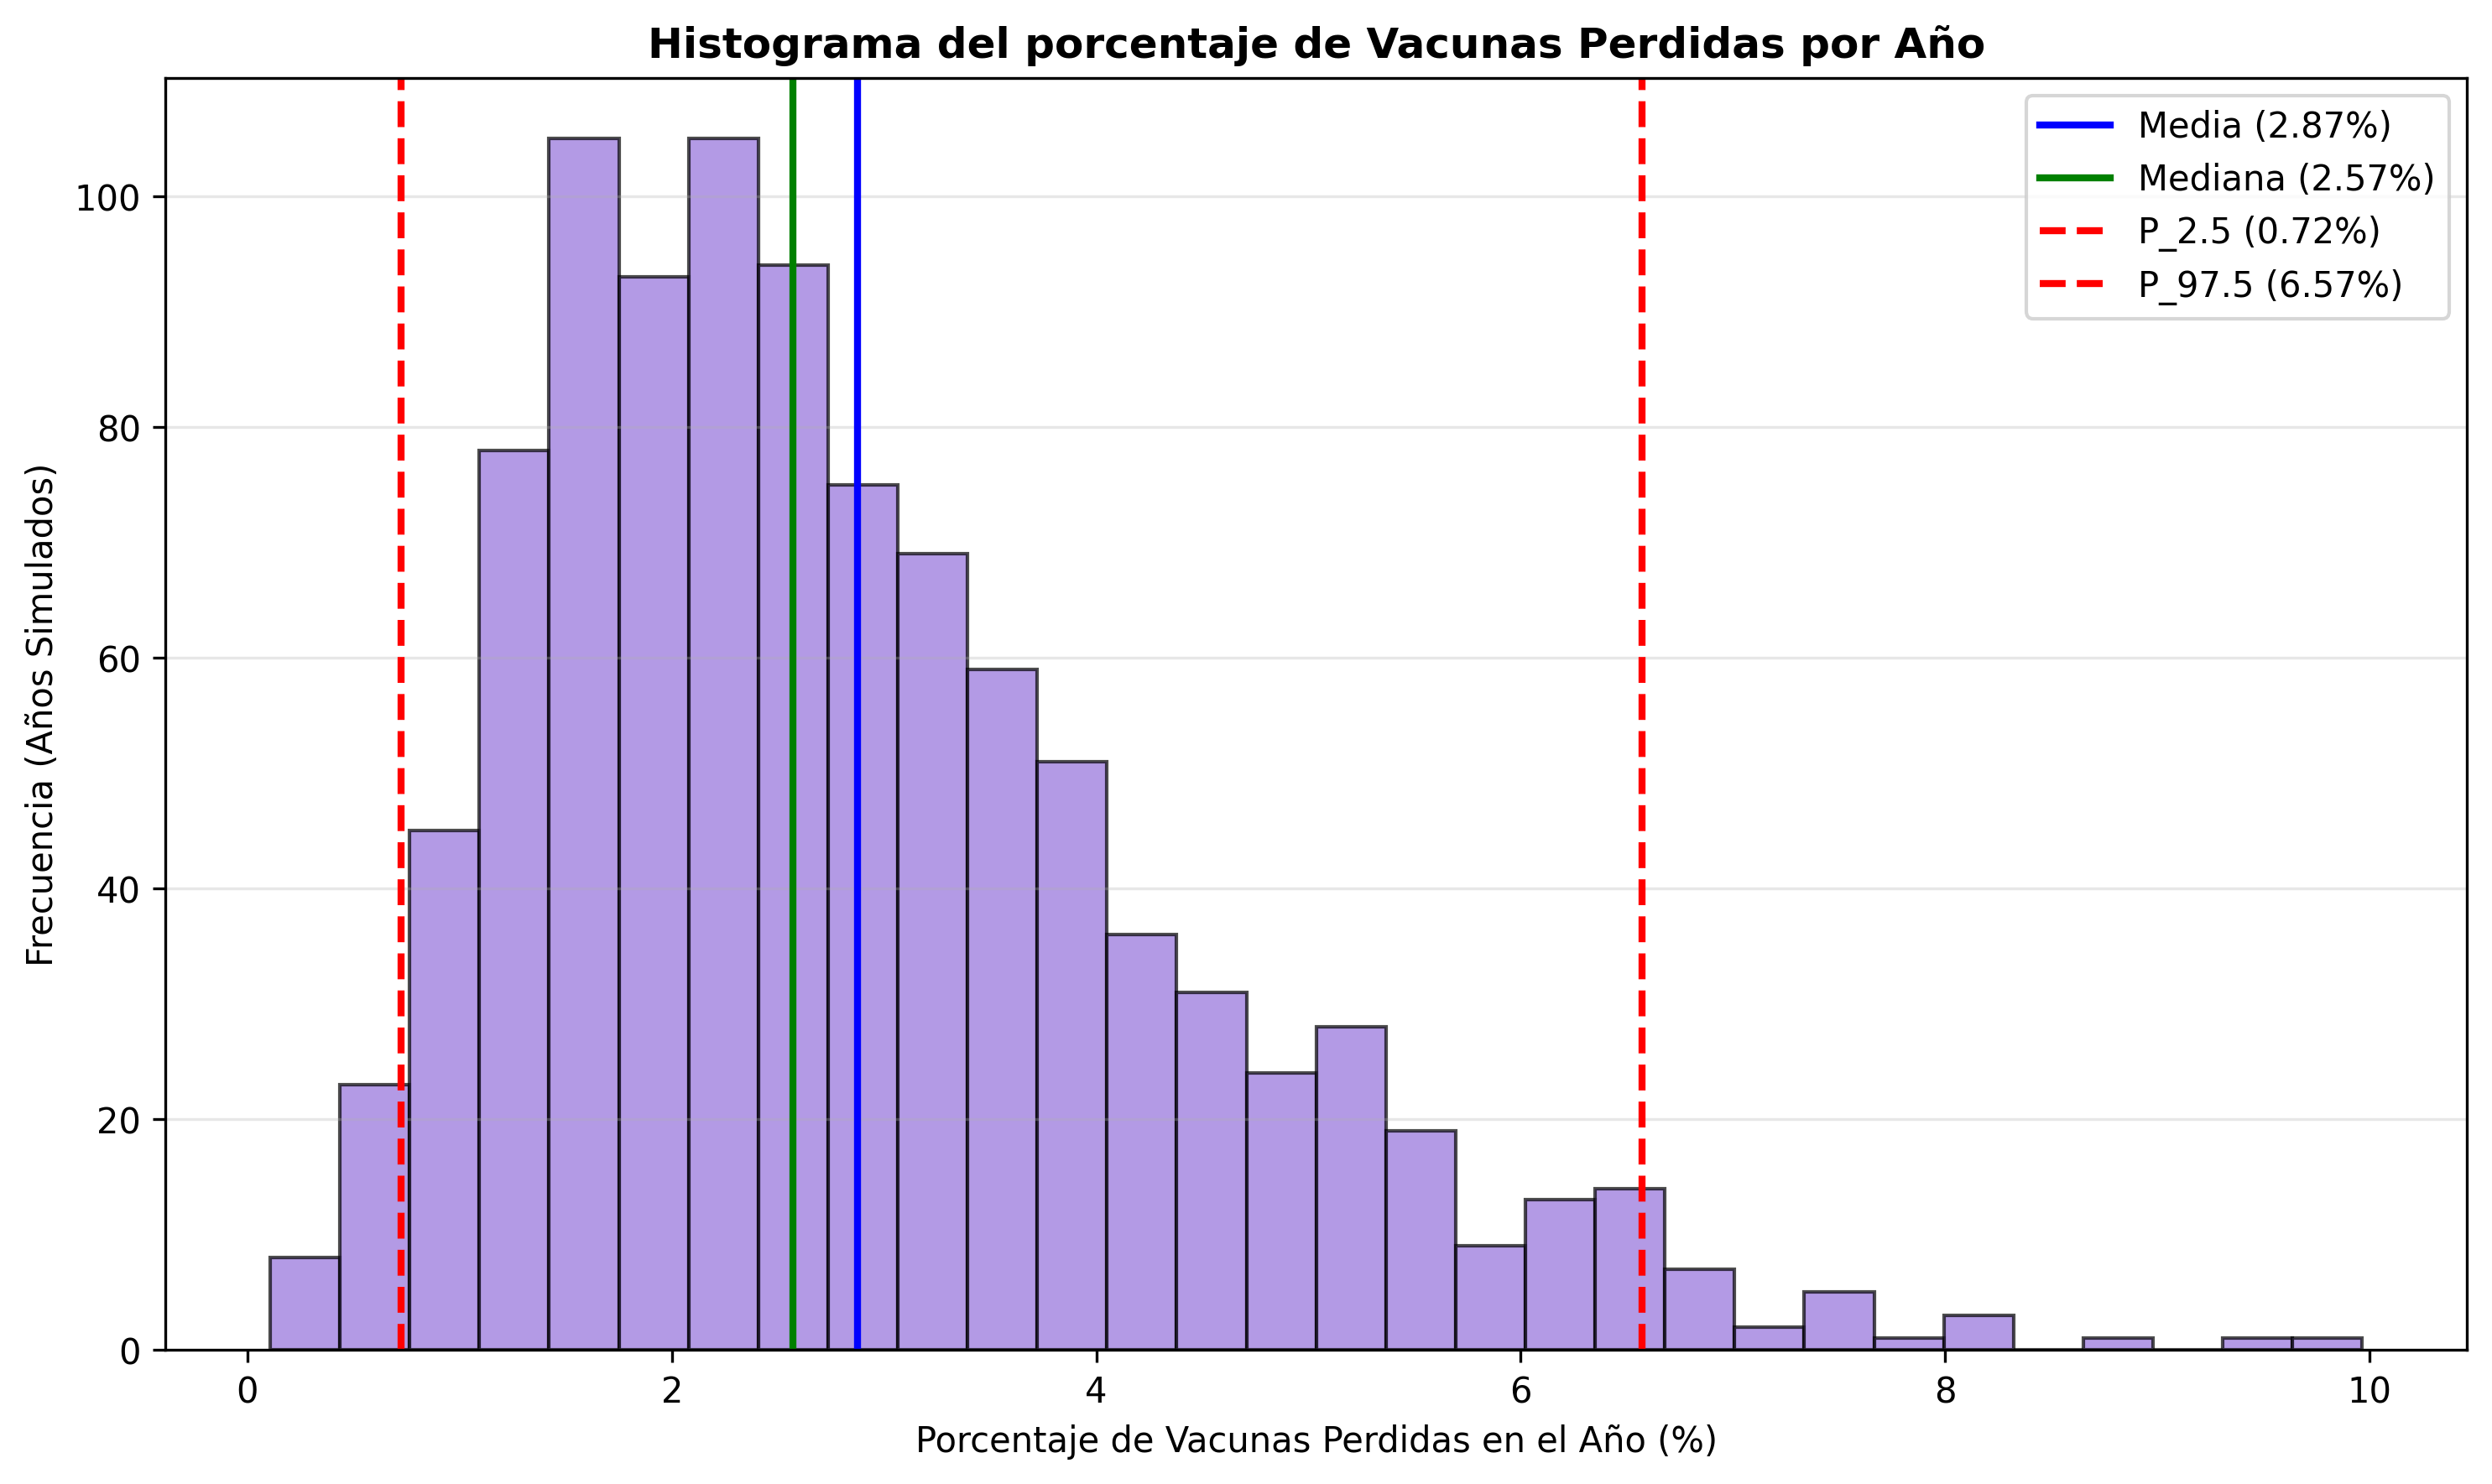

In [ ]:
# 1. EXTRAER DATOS A ARREGLOS DE NUMPY
mermas_anuales = np.array([res['merma_anual'] for res in resultados_mc])
dosis_ingresadas = np.array([res['dosis_totales_ingresadas'] for res in resultados_mc])
apagones_anuales = np.array([res['total_apagones'] for res in resultados_mc])
aperturas_anuales = np.array([res['total_aperturas'] for res in resultados_mc])
mermas_mensuales = np.array([res['merma_por_mes'] for res in resultados_mc])

# 2. ESTADÍSTICAS DESCRIPTIVAS (DOSIS ABSOLUTAS Y PORCENTAJES)
# Porcentajes
porcentajes_perdida = (mermas_anuales / dosis_ingresadas) * 100
media_porcentaje = np.mean(porcentajes_perdida)
mediana_porcentaje = np.median(porcentajes_perdida)
p_025 = np.percentile(porcentajes_perdida, 2.5)
p_975 = np.percentile(porcentajes_perdida, 97.5)

# Dosis Absolutas
media_dosis = np.mean(mermas_anuales)
mediana_dosis = np.median(mermas_anuales)
p_95_dosis = np.percentile(mermas_anuales, 95)

print("REPORTE ESTADÍSTICO DE LA RED DE FRÍO")
print(f"Trayectorias Simuladas: {N_SIMULACIONES} años")
print("\n--- Variables de Control Operativo ---")
print(f"Apagones promedio: {np.mean(apagones_anuales):.1f} por año")
print(f"Aperturas promedio: {np.mean(aperturas_anuales):.0f} por año")

print("\n--- Análisis de Riesgo (Dosis Perdidas por Refrigerador) ---")
print(f"Mediana de pérdidas anuales: {mediana_dosis:.0f} dosis")
print(f"Promedio de pérdidas anuales: {media_dosis:.0f} dosis")
print(f"Riesgo Severo (Percentil 95): {p_95_dosis:.0f} dosis (En el 95% de los años, no se perderan más de esto)")

print("\n--- Análisis de Riesgo (Porcentaje de Merma) ---")
print(f"Mediana de pérdida: {mediana_porcentaje:.2f}%")
print(f"Promedio de pérdida: {media_porcentaje:.2f}%")
print(f"Intervalo del 95%: Entre {p_025:.2f}% y {p_975:.2f}%")

# GRÁFICAS (4 PANELES SEPARADOS)
# --- GRÁFICA 1: TRAYECTORIAS (30) ---
plt.figure(figsize=(10, 5), dpi=300)
trayectorias_a_graficar = 30

for i in range(trayectorias_a_graficar):
    trayectoria = resultados_mc[i]['trayectoria_merma']
    plt.plot(t_horas/24, trayectoria, alpha=0.4, linewidth=1.2)

plt.title(f'Perdidas de Dosis ({trayectorias_a_graficar} trayectorias)', fontweight='bold')
plt.xlabel('Días del año')
plt.ylabel('Vacunas Perdidas (Dosis)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('abanico_riesgo.png', dpi=300)
plt.show()

# --- GRÁFICA 2: PROMEDIO MENSUAL DE MERMAS ---
plt.figure(figsize=(10, 5), dpi=300)
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
promedio_mensual = np.mean(mermas_mensuales, axis=0)

plt.bar(meses_labels, promedio_mensual, color='skyblue', alpha=0.8, edgecolor='black')
plt.title('Pérdida PROMEDIO de Vacunas por Mes', fontweight='bold')
plt.xlabel('Mes del Año')
plt.ylabel('Promedio de Dosis Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barras_estacionales_promedio.png', dpi=300)
plt.show()

# --- GRÁFICA 3: MEDIANA MENSUAL DE MERMAS ---
plt.figure(figsize=(10, 5), dpi=300)
mediana_mensual = np.median(mermas_mensuales, axis=0)
plt.bar(meses_labels, mediana_mensual, color='skyblue', alpha=0.8, edgecolor='black')
plt.title('Pérdida MEDIANA de Vacunas por Mes', fontweight='bold')
plt.xlabel('Mes del Año')
plt.ylabel('Mediana de Dosis Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barras_estacionales_mediana.png', dpi=300)
plt.show()

# --- GRÁFICA 4: HISTOGRAMA DE RIESGO ---
plt.figure(figsize=(10, 6), dpi=300)

n, bins, patches = plt.hist(porcentajes_perdida, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)

# Líneas Estadísticas
plt.axvline(media_porcentaje, color='blue', linestyle='-', linewidth=2, label=f'Media ({media_porcentaje:.2f}%)')
plt.axvline(mediana_porcentaje, color='green', linestyle='-', linewidth=2, label=f'Mediana ({mediana_porcentaje:.2f}%)')
plt.axvline(p_025, color='red', linestyle='--', linewidth=2, label=f'P_2.5 ({p_025:.2f}%)')
plt.axvline(p_975, color='red', linestyle='--', linewidth=2, label=f'P_97.5 ({p_975:.2f}%)')

plt.title('Histograma del porcentaje de Vacunas Perdidas por Año', fontweight='bold', fontsize=12)
plt.xlabel('Porcentaje de Vacunas Perdidas en el Año (%)')
plt.ylabel('Frecuencia (Años Simulados)')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_porcentajes.png', dpi=300)
plt.show()